# This notebook regroups all the code around graph formation/cost prescription estimation (AKM estimator using pytwoway and another estimation using Linear Regression)

This a notebook has been initially written by Arthur Sabre and has been thereafter improved by Vincent Gimenes

## Packages and Import

Version de python utilisé pour pytwoway : 3.10 (3.10.12 or 3.10.13 is fine). Il n'est pas nécessaire d'utiliser pytwoway pour utiliser ce notebook, il faut simplement sauter la section "estimation using pytwoway"

In [173]:
#!pip install pytwoway (Python version used for pytwoway : 3.10 (3.10.12 or 3.10.13 is fine)
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install bipartitepandas
#!pip install umap-learn

In [172]:
import matplotlib.pyplot as plt
import pandas as pd
#import pytwoway as tw
import bipartitepandas as bpd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
import time
import random
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour visualisation
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn import metrics


from warnings import simplefilter
from sklearn.preprocessing import LabelEncoder
# Ignore warnings below
# Optimisation via tensorflow.keras
from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Formation du graphe

In [119]:
MEAN=2
STD=0
def graph_formation(n_patients,
                    n_doctors,
                    max_number_connections,
                    z=1.42,
                    type_distance="default",
                    beta_age_p_graph=0.2,
                    beta_age_d_graph=0.2,
                    beta_informed_p_graph=1,
                    beta_skilled_d_graph= 1,
                    beta_distance_graph= -20,
                    nb_latent_factors = 1,
                    alpha_law_weights = [0.3, 0.3, 0.4] ,
                    alpha_law_means = np.array([0, 1, 2])*MEAN,
                    alpha_law_stds = np.array([1.2, 1, 0.9])*STD,
                    psi_law_weights = [0.6, 0.4],
                    psi_law_means = np.array([0, 1])*MEAN,
                    psi_law_stds = np.array([1, 0.7])*STD,
                    ):
    """
    Creates only the graph formation part and returns the associated dataframe
    """
    coor_patients = []
    coor_doctors = []
    alpha_graph = []
    alpha_class = []
    psi_graph = []
    psi_class = []
    rng = np.random.default_rng(None)
    D = np.zeros([n_patients, n_doctors], dtype = np.ndarray)

    # Change the parameters to numpy array (if it is not already the case)
    alpha_law_weights, alpha_law_means, alpha_law_stds =  np.array(alpha_law_weights), np.array(alpha_law_means), np.array(alpha_law_stds)
    psi_law_weights, psi_law_means, psi_law_stds =  np.array(psi_law_weights), np.array(psi_law_means), np.array(psi_law_stds)

    # To be sure that weights are normalized
    alpha_law_weights = alpha_law_weights / alpha_law_weights.sum()
    psi_law_weights = psi_law_weights / psi_law_weights.sum()

    # Count the number of class possible
    nb_class_alpha = len(alpha_law_weights)
    nb_class_psi = len(psi_law_weights)

    ### Simulation d'un mélange gaussien pour les effets fixes ###

    for i in range(n_patients):
        
        # Assign randomly a class with respect to the distribution given by the weights
        alpha_class.append( np.random.choice( np.arange(nb_class_alpha), p=alpha_law_weights) )
        # We generate the FE for the graph formation model
        alpha_graph.append( np.random.normal( alpha_law_means[ alpha_class[-1] ], alpha_law_stds[ alpha_class[-1] ], size = 1) )

    for j in range(n_doctors):
        
        # Assign randomly a class with respect to the distribution given by the weights
        psi_class.append( np.random.choice( np.arange(nb_class_psi) , p=psi_law_weights) )
        # We generate the FE for the graph formation model
        psi_graph.append( np.random.normal( psi_law_means[psi_class[-1]], psi_law_stds[psi_class[-1]], size = 1 ) )
        

    # Generate distance matrix
    if type_distance == 'default':
        for i in range(n_patients):
            # Generate the coordinates of the patients
            coor_patients.append( np.random.uniform(0, 1, 2) )
            for j in range(n_doctors):
                if i == 0: # We ensure each coordinate is generated once for each doctor
                    # Generate the coordinates of the doctors
                    coor_doctors.append( np.random.uniform(0, 1, 2) )
                d = np.sqrt(np.power((coor_patients[i][0] - coor_doctors[j][0]), 2) + np.power((coor_patients[i][1] - coor_doctors[j][1]), 2))
                D[i][j] = d

    else:

        # Assign randomly a CODGEO, DEP, or REG to patients and doctors
        dist_matrix = pd.read_csv('Data/' + type_distance + '.csv')
        
        del dist_matrix[dist_matrix.columns[0]]
        dist_matrix.index = dist_matrix.columns
        for i in range(len(dist_matrix)):
            dist_matrix.iloc[i, i] = 0
        arr = dist_matrix.columns.values
        for i, col in enumerate(arr):
            arr[i] = int(float(arr[i]))
        dist_matrix.columns = arr
        dist_matrix.index = arr

        # Generate code for patient and doctor
        code_patient = []
        code_doctor = []
        for i in range(n_patients):
            random_code = np.random.choice(dist_matrix.columns.values)
            code_patient.append( random_code )
        for j in range(n_doctors):
            random_code = np.random.choice(dist_matrix.columns.values)
            code_doctor.append( random_code )
        for i in range(n_patients):
            for j in range(n_doctors):
                D[i, j] = dist_matrix.loc[code_patient[i], code_doctor[j]]

    D_normed = ( D - D.mean() ) / D.std()
    # Random draws of ages for patients and doctors
    sim_patient_age = rng.integers(low = 1, high = 99, size = n_patients)
    sim_patient_age_normed = ( sim_patient_age - sim_patient_age.mean() ) / sim_patient_age.std()
    sim_doctor_age = rng.integers(low = 26, high = 99, size = n_doctors)
    sim_doctor_age_normed = ( sim_doctor_age - sim_doctor_age.mean() ) / sim_doctor_age.std()

    # Random draws of genders of patients and doctors

    # !!! I changed the gender of the doctor or the patient by a variable which worth 1 if the doctor is skilled or if the patient is inforemd 0 otherwise
    
    sim_patient_informed = np.random.choice(np.array([0, 1]), n_patients)
    sim_doctor_skilled = np.random.choice(np.array([0, 1]), n_doctors)
    
    # sim_patient_gender = rng.integers(low = 1, high = 3, size = n_patients)
    # sim_doctor_gender = rng.integers(low = 1, high = 3, size = n_doctors)
    #sim_patient_gender_normed = ( sim_patient_gender - sim_patient_gender.mean() ) / sim_patient_gender.std()
    #sim_doctor_gender_normed = ( sim_doctor_gender - sim_doctor_gender.mean() ) / sim_doctor_gender.std()

    # Bias for patients and doctors
    # bias_patient = np.random.normal(0, 1, size = n_patients)
    # bias_doctor = np.random.normal(0, 1, size = n_doctors)

    # Compile ids
    id_p = np.repeat(range(n_patients), n_doctors)
    id_d = np.tile(range(n_doctors), n_patients)

    # Compile observed features
    age_p_data = np.repeat(sim_patient_age, n_doctors)
    age_d_data = np.tile(sim_doctor_age, n_patients)
    informed_p_data = np.repeat(sim_patient_informed, n_doctors)
    skilled_d_data = np.tile(sim_doctor_skilled, n_patients)
    # bias_patient_data = np.repeat(bias_patient, n_doctors)
    # bias_doctor_data = np.tile(bias_doctor, n_patients)
    ef_patient_data = np.repeat(alpha_graph, n_doctors)
    ef_doctor_data = np.tile(psi_graph, n_patients)

    class_patient_data = np.repeat(alpha_class, n_doctors)
    class_doctor_data = np.tile(psi_class, n_patients)

    if type_distance != 'default':
        code_patient_data = np.repeat(code_patient, n_doctors)
        code_doctor_data = np.tile(code_doctor, n_patients)
    # # P is the matrix with all the connection probabilities
    # P = np.zeros((n_patients, n_doctors))
    # Generate the identifier matrix A based on the distance
    A = np.zeros([n_patients, n_doctors], dtype = np.ndarray)
    for i in range(n_patients):
        for j in range(n_doctors):
            if D[i][j] <= z: # if patient i and doctor j are too far away, there is no relation
                T = alpha_graph[i] + psi_graph[j] + beta_age_p_graph * sim_patient_age_normed[i] + beta_age_d_graph * sim_doctor_age_normed[j] \
                + beta_informed_p_graph * sim_patient_informed[i] + beta_skilled_d_graph * sim_doctor_skilled[j] + beta_distance_graph * D[i][j]
                p = 1 / (1 + np.exp(-T))
                # P[i][j] = p
                A[i][j] = np.random.binomial(1, p)
    
    # Compile relations between doctors and patients
    relation = A.flatten()

    # Merge all columns into a dataframe
    dataframe = pd.DataFrame(data={'i': id_p, 'j': id_d, 'y' : relation, 'age_p': age_p_data, 'age_d': age_d_data, 
                           'informed_p': informed_p_data, 'skilled_d': skilled_d_data, 'class_p': class_patient_data, 'class_d': class_doctor_data
                            })
    dataframe['distance'] = D[dataframe['i'], dataframe['j']].astype(float)

        # Now, we bound the number of connections (1 <= connections <= max_number_connections)
    # First, we detect the patients who have 0 connection.
    number_of_connections = dataframe.groupby('i').agg({'y': 'sum'})
    zero_connection = number_of_connections[number_of_connections['y'] == 0].index
    for patient in zero_connection:
        # If patient has zero connection, we connect him with the nearest doctor (even if the threshold z isn't respected)
        min_index = dataframe[dataframe['i'] == patient]['distance'].idxmin()
        doctor_to_connect = dataframe.loc[min_index, 'j']
        dataframe.loc[(dataframe['i'] == patient) & (dataframe['j'] == doctor_to_connect), 'y'] = 1
    
    # Then, we detect the patients who have more than max_number_connections. We choose the remaining connections by doctor's popularities (possible to choose randomly).
    number_of_connections = dataframe.groupby('i').agg({'y': 'sum'})
    too_much_connection = number_of_connections[number_of_connections['y'] > max_number_connections].index
    for patient in too_much_connection:
        # We keep the connections with the most popular doctors
        patient_df = dataframe[dataframe['i'] == patient]
        connected_doctors = patient_df[patient_df['y'] == 1]['j'].values
        most_popular_doctors = dataframe[dataframe['j'].isin(connected_doctors)].groupby('j').agg({'y': 'sum'}).sort_values('y', ascending=False)
        not_kept_doctors = most_popular_doctors.index[max_number_connections:].values
        for doctor in not_kept_doctors:
            dataframe.loc[(dataframe['i'] == patient) & (dataframe['j'] == doctor), 'y'] = 0

        # # We keep the connections choosing randomly
        # patient_df = dataframe[dataframe['i'] == patient]
        # connected_doctors = patient_df[patient_df['y'] == 1]['j'].values
        # not_kept_doctors = np.random.choice(connected_doctors, size=len(connected_doctors) - max_number_connections, replace=False)
        # for doctor in not_kept_doctors:
        #     dataframe[(dataframe['i'] == patient) & (dataframe['j'] == doctor)]['y'] = 0

    # Create a dataframe of fixed effects for patients and doctors, then concatenate it with all the data
    k = len(alpha_graph[0]) # Number of latent factors
    ef_patient = pd.DataFrame(np.zeros((n_patients*n_doctors, k)))
    ef_doctor = pd.DataFrame(np.zeros((n_patients*n_doctors, k)))
    for i in range(k):
        ef_patient_element = []
        ef_doctor_element = []
        ef_patient.rename(columns = {i :f'ef_p_{i}'}, inplace = True)
        ef_doctor.rename(columns = {i :f'ef_d_{i}'}, inplace = True)
        for j in range(n_patients):
            
            ef_patient_element += list(np.repeat(alpha_graph[j][i], n_doctors))

        for j in range(n_doctors):
            ef_doctor_element.append(psi_graph[j][i])
        
        ef_patient[f'ef_p_{i}'] = ef_patient_element
        ef_doctor[f'ef_d_{i}'] = np.tile(ef_doctor_element, n_patients)
    dataframe = pd.concat([dataframe, ef_patient, ef_doctor], axis = 1)
    dataframe = dataframe.reset_index().drop(['index'], axis = 1)
    return dataframe, alpha_graph, psi_graph, alpha_class, psi_class, coor_patients, coor_doctors, D,  beta_age_p_graph, beta_age_d_graph, beta_informed_p_graph, beta_skilled_d_graph,beta_distance_graph, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled

In [126]:
graph_all= graph_formation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                     z=1.4  ,
                    beta_distance_graph = -20)
df, alpha_graph, psi_graph, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all
df['y'] = df['y'].astype("int")

In [127]:
density = df[df['y']==1].shape[0]/df.shape[0]
print(f"density of the graph: {density*100}%")

density of the graph: 71.004%


## cost prescription computation 

Then, cost_prescription computes the cost prescriptions of the graph created.

Cette cellule est mystérieuse ...

In [7]:
def cost_prescription  (df,
                        z=np.sqrt(2),
                        alpha_law_cost=(0, 0.5),
                        psi_law_cost=(0, 0.5),
                        beta_age_p_cost=0.5,
                        beta_age_d_cost=0.5,
                        beta_sex_p_cost=0.5,
                        beta_sex_d_cost=0.5,
                        beta_distance_cost=-0.5):

        # drop the rows if there is no relation between patient_i and doctor_j
        patients = df['i'].unique()
        doctors = df['j'].unique()
        dataframe = df.copy()
        dataframe = dataframe.drop(dataframe[dataframe['y'] == 0].index)
        dataframe = dataframe.drop(['y'], axis = 1)
        dataframe = dataframe.reset_index().drop(['index'], axis = 1)

        alpha_cost = {} # These are dicts to use the function map later
        psi_cost = {}

        #for i in patients:
        
            # We generate the FE for the cost model
            #alpha_cost[i] = np.random.uniform(alpha_law_cost[0], alpha_law_cost[1])
                               
        #for j in doctors:

            # We generate the FE for the cost model
            #psi_cost[j] = np.random.uniform(psi_law_cost[0], psi_law_cost[1])

        #dataframe['cost_EF_patient'] = dataframe['i'].map(alpha_cost).astype(float)
        #dataframe['cost_EF_doctor'] = dataframe['j'].map(psi_cost).astype(float)
        # dataframe['distance'] = D[dataframe['i'], dataframe['j']].astype(float)

        # Compute the cost
        dataframe['y'] = dataframe['ef_p_0'] + dataframe['ef_d_0'] + beta_age_p_cost * dataframe['age_p'] + beta_age_d_cost * dataframe['age_d'] + beta_sex_p_cost * dataframe['sex_p'] + beta_sex_d_cost * dataframe['sex_d'] + beta_distance_cost * dataframe['distance']
        cost_column = dataframe.pop('y')
        dataframe.insert(2, 'y', cost_column)

        return dataframe

In [8]:
df_cost = cost_prescription(df)

Here's the part about estimation using linear regression, without the pytwoway library.

In [9]:
def cost_estimate(df):
    # We estimate the FE for the cost model using LinearRegression

    model = LinearRegression()
    patients = df['i'].unique()
    doctors = df['j'].unique()
    n_patients = len(patients)
    n_doctors = len(doctors)

    # Add dummy variables
    e_i_cost = pd.DataFrame(np.zeros((len(df), n_patients), dtype=int))
    for i,patient in enumerate(patients):
        e_i_cost.rename(columns = {i :f'p_{patient}'}, inplace = True)
        
    e_j_cost = pd.DataFrame(np.zeros((len(df), n_doctors), dtype=int))
    for j,doctor in enumerate(doctors):
        e_j_cost.rename(columns = {j :f'd_{doctor}'}, inplace = True)
    
    df2 = pd.concat([df, e_i_cost, e_j_cost], axis = 1)
    
    for i in patients:
        indexes = df2[df2['i'] == i].index
        df2[f'p_{i}'][indexes] = [1 for i in range(len(indexes))]
    
    for j in doctors:
        indexes = df2[df2['j'] == j].index
        df2[f'd_{j}'][indexes] = [1 for i in range(len(indexes))]

    # Scale specific columns
    df2['age_p'] =( df['age_p'] - df['age_p'].mean() ) / df['age_p'].std()
    df2['age_d'] =( df['age_d'] - df['age_d'].mean() ) / df['age_d'].std()
    
    y = df2['y'].astype(int)
    X = df2.drop(['i', 'j', 'y', 'ef_p_0', 'ef_d_0', 'class_p', 'class_d'], axis = 1)
    
    regression = model.fit(X, y)
    estimates = regression.coef_

    return estimates

In [10]:
estimates = cost_estimate(df_cost)
estimates.shape

C:\Users\vince\AppData\Local\Temp\ipykernel_14180\791963410.py:23: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2[f'p_{i}'][indexes] = [1 for i in range(len(indexes))]
C:\Users\vince\AppData\Local\Temp\ipykernel_14180\791963410.py:23: Fut

(72, 320)

In [13]:
estimates

array([[-1.15835309, -1.07739442, -0.50265205, ..., -0.06110886,
        -0.04499711, -0.00575604],
       [-1.09801734, -1.06846484, -0.50248728, ..., -0.06160546,
        -0.04447235, -0.00565578],
       [-0.92597696, -1.06513851,  0.27767555, ..., -0.06630983,
        -0.05856346, -0.00672896],
       ...,
       [ 0.91293698,  0.88562047,  0.23562939, ..., -0.023934  ,
        -0.02088662,  0.78677079],
       [ 1.95502313,  1.16303628,  0.06619142, ..., -0.0431057 ,
        -0.03501348, -0.16981667],
       [ 1.12762322,  0.83724071,  0.25481591, ..., -0.02479366,
        -0.02306616, -0.07384686]])

## Estimation using pytwoway

Estimation using pytwoway. You might want to use 3.10.12 Python version in order to install pytwoway as there are problems installing it using latest Python versions (see https://github.com/arthursabre/Stage-2A/blob/main/requirements.txt for all the versions of my packages used during the implementation).

In [12]:
df['y'] = df['y'].astype("float")

In [14]:
def cost_estimate_pytwoway(df,
                           type_distance='default',
                           preconditioner='ichol'):

    fecontrol_params = tw.fecontrol_params(
    {
        'ho': True,
        'he': False,
        'feonly': True,
        'continuous_controls': ['distance', 'age_d', 'age_p'],
        'categorical_controls': ['sex_p', 'sex_d'],
        'attach_fe_estimates': True,
        'ncore': 8,
        'preconditioner': preconditioner # It looks like it gives better results (especially for large datasets ?)
    }
    )

    clean_params = bpd.clean_params(
    {
        'connectedness': 'leave_out_spell',
        'collapse_at_connectedness_measure': True,
        'drop_single_stayers': True,
        'drop_returns': 'returners',
        'copy': False
    }
    )

    dataframe = df.copy()
    # Scale specific columns
    dataframe['age_p'] =( dataframe['age_p'] - dataframe['age_p'].mean() ) / dataframe['age_p'].std()
    dataframe['age_d'] =( dataframe['age_d'] - dataframe['age_d'].mean() ) / dataframe['age_d'].std()
     # Change dtype of categorical variables
    dataframe['sex_p'] = dataframe['sex_p'].astype("category")
    dataframe['sex_d'] = dataframe['sex_d'].astype("category")
    # We create a BipartiteDataFrame in order to estimate the FE for the cost model
    if type_distance == 'default':
        
        bdf = bpd.BipartiteDataFrame(dataframe.drop(['ef_p_0', 'ef_d_0', "class_d", "class_p"] , axis = 1),
                                    custom_categorical_dict = {'sex_p': True,
                                                            'sex_d': True},
                                    custom_dtype_dict = {'sex_p': 'categorical',
                                                        'sex_d': 'categorical'},
                                    custom_how_collapse_dict = {'sex_p': 'first',
                                                                'sex_d': 'first'}) # We transform the dataframe as BipartitePandas dataframe to Estimate the FE.
    else:
        
        bdf = bpd.BipartiteDataFrame(dataframe.drop(['ef_p_0', 'ef_d_0', "class_d", "class_p", 'code_patient', 'code_doctor'] , axis = 1),
                                    custom_categorical_dict = {'sex_p': True,
                                                            'sex_d': True},
                                    custom_dtype_dict = {'sex_p': 'categorical',
                                                        'sex_d': 'categorical'},
                                    custom_how_collapse_dict = {'sex_p': 'first',
                                                                'sex_d': 'first'}) # We transform the dataframe as BipartitePandas dataframe to Estimate the FE.


    bdf.clean(clean_params)
    fe_estimator = tw.FEControlEstimator(bdf, fecontrol_params)
    fe_estimator.fit()

    return fe_estimator.gamma_hat_dict # Estimates of the EF, Beta for the cost model

In [196]:
df.dtypes

i             int32
j             int32
y           float64
age_p         int64
age_d         int64
sex_p         int32
sex_d         int32
class_p       int32
class_d       int32
distance    float64
ef_p_0      float64
ef_d_0      float64
dtype: object

In [192]:
cost_estimate_pytwoway(df)

checking required columns and datatypes
sorting rows
dropping NaN observations
generating 'm' column
dropping duplicate observations
dropping workers who leave a firm then return to it (how='returners')
making 'i' ids contiguous
making 'j' ids contiguous
making 'sex_p' ids contiguous
making 'sex_d' ids contiguous
computing largest connected set (how=None)
sorting columns
resetting index
checking required columns and datatypes
sorting rows
generating 'm' column
computing largest connected set (how='leave_out_observation')
sorting columns
resetting index


ValueError: column index exceeds matrix dimensions

## Matrix factorization with an embedding of dimension 1 + Hard negative sampling

### Fonction MF

In [151]:
#tf.compat.v1.config.run_functions_eagerly(True)
#tf.compat.v1.disable_eager_execution()
# Pour arrêter la descente lorsque la loss est suffisamment faible
class StopTrainingBelowLoss(Callback):
    def __init__(self, target_loss):
        super(StopTrainingBelowLoss, self).__init__()
        self.target_loss = target_loss

    def on_epoch_end(self, epoch, logs=None):
        if logs.get('loss') is not None and logs.get('loss') < self.target_loss:
            print(f"\nTraining stopped as the loss reached below {self.target_loss}")
            self.model.stop_training = True

# Récupérer la valeur de la loss (utile si on ne fixe pas de seuil à atteindre)
class LossHistory(Callback):
    def __init__(self):
        super(LossHistory, self).__init__()
        self.losses = []

    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs.get('loss'))

def get_estimations(df, nb_epochs=50, initial_weights=None, target_loss=None, show_print=1, l_lambda=1e-7, regularization="l2"):
    """Etant donné un dataframe, get_estimations renvoie l'estimation des effets fixes et des Bêtas en utilisant TensorFlow.keras

    Args:
        df (_type_): le dataframe pour lequel on souhaite obtenir l'estimation
        nb_epochs (int, optional): Le nombre d'itérations pour notre descente de gradient. Defaults to 50.
        initial_weights (_type_, optional): Si on a déjà lancé un entraînement et qu'on souhaite le poursuivre, on peut rentrer l'estimation obtenue auparavant
        (voir plus bas pour un exemple). Defaults to None.
        target_loss (_type_, optional): Si une valeur est indiquée, la descente de gradient ne s'arrête pas tant que la loss n'est pas inférieure
        à cette valeur. Defaults to None.

    Returns:
        _type_: l'ensemble des estimations (voir plus bas pour un exemple)
    """
    # Définition des dimensions
    num_patients = df['i'].nunique()
    num_doctors = df['j'].nunique()

    # Créer un LabelEncoder pour les ID des patients et des docteurs, utile si les id ne sont pas nécessairement une suite consécutive d'entiers (1, 2, ..., n)
    patient_encoder = LabelEncoder()
    i_encoded = patient_encoder.fit_transform(df['i'])

    doctor_encoder = LabelEncoder()
    j_encoded = doctor_encoder.fit_transform(df['j'])

    # Enregistrer les mappings ID -> entier pour retrouver les bons indices associés à chaque patient/docteur si besoin
    patient_id_mapping = dict(zip(patient_encoder.classes_, range(num_patients)))
    doctor_id_mapping = dict(zip(doctor_encoder.classes_, range(num_doctors)))

    y = df['y'].values.astype(np.float32)
    df = df.astype(np.float32)
    X = [i_encoded, j_encoded, df['age_p'].values, df['age_d'].values, df['informed_p'].values,\
            df['skilled_d'].values, df['distance'].values]
    
    # Entrées du modèle
    user_input = Input(shape=(1,), name="i")
    doctor_input = Input(shape=(1,), name="j")
    age_patient_input = Input(shape=(1,), name='age_p')
    age_doctor_input = Input(shape=(1,), name='age_d')
    informed_patient_input = Input(shape=(1,), name='informed_p')
    skilled_doctor_input = Input(shape=(1,), name='skilled_d')
    distance_input = Input(shape=(1,), name="distance")

    # Incorporation des utilisateurs et des docteurs dans des espaces latents
    if regularization == "l1":
        
        user_embedding = Embedding(name = 'patient_embedding', input_dim=num_patients, output_dim=1, input_length=1,embeddings_regularizer=regularizers.l1(l_lambda))(user_input)
        doctor_embedding = Embedding(name = 'doctor_embedding', input_dim=num_doctors, output_dim=1, input_length=1,embeddings_regularizer=regularizers.l1(l_lambda))(doctor_input)
    elif regularization == "l2":
        user_embedding = Embedding(name = 'patient_embedding', input_dim=num_patients, output_dim=1, input_length=1,embeddings_regularizer=regularizers.l2(l_lambda))(user_input)
        doctor_embedding = Embedding(name = 'doctor_embedding', input_dim=num_doctors, output_dim=1, input_length=1,embeddings_regularizer=regularizers.l2(l_lambda))(doctor_input)
    else:
        raise ValueError("the regularization parameter must be 'l1' or 'l2'")
    
    # Obtention des vecteurs latents des utilisateurs et des docteurs
    user_latent = Flatten()(user_embedding)
    doctor_latent = Flatten()(doctor_embedding)

    # Produit scalaire entre les vecteurs latents des utilisateurs et des docteurs
    #dot_product = Dot(axes=1)([user_latent, doctor_latent])

    # Création d'une couche pour paramétriser les Beta
    class CustomLayer(Layer):
        def __init__(self, **kwargs):
            super(CustomLayer, self).__init__(**kwargs)

        def build(self, input_shape):
            self.beta_age_patient = self.add_weight(shape=(1,), initializer='random_normal', trainable=True)
            self.beta_age_doctor = self.add_weight(shape=(1,), initializer='random_normal', trainable=True)
            self.beta_informed_patient = self.add_weight(shape=(1,), initializer='random_normal', trainable=True)
            self.beta_skilled_doctor = self.add_weight(shape=(1,), initializer='random_normal', trainable=True)
            self.beta_distance = self.add_weight(shape=(1,), initializer='random_normal', trainable=True)
            super(CustomLayer, self).build(input_shape)

        def call(self, inputs):
            age_patient_input, age_doctor_input, informed_patient_input, skilled_doctor_input, distance_input = inputs
            linear_term = self.beta_age_patient * age_patient_input + \
                        self.beta_age_doctor * age_doctor_input + \
                        self.beta_informed_patient * informed_patient_input + \
                        self.beta_skilled_doctor * skilled_doctor_input + \
                        self.beta_distance * distance_input
            return linear_term

    # Ajout de la couche personnalisée dans le modèle
    linear_term = CustomLayer()([age_patient_input, age_doctor_input, informed_patient_input, skilled_doctor_input, distance_input])  # X*beta
    output = Add()([user_latent, doctor_latent, linear_term]) # X*beta + psi_i + alpha_j
    output = Activation('sigmoid')(output)  # sigma(.)

    # Création du modèle
    model = Model(inputs=[user_input, doctor_input, age_patient_input, age_doctor_input, informed_patient_input, skilled_doctor_input, distance_input], outputs=output)

    # Compilation du modèle
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Chargement des poids initiaux si disponibles (utile pour reprendre l'entraînement)
    if initial_weights != None:
        model.set_weights(initial_weights)

    # Ajout du rappel pour arrêter l'entraînement seulement si la perte atteint un seuil
    if target_loss != None:
        callbacks = []
        callbacks.append(StopTrainingBelowLoss(target_loss))
        # Initialisation du nombre d'époques
        epoch = 0
    # Boucle d'entraînement jusqu'à ce que la perte atteigne le seuil
        while True:
            # Entraînement d'une époque
            history = model.fit(X, y, epochs=1, batch_size=64, validation_split=0.2, verbose=show_print, callbacks=callbacks)

            # Incrémentation du nombre d'époques
            epoch += 1

            # Vérification si l'entraînement doit être arrêté
            if model.stop_training:
                break
        return epoch, model.get_weights(), patient_id_mapping, doctor_id_mapping, model
    else:
        # Ajout du rappel pour enregistrer la perte
        loss_history = LossHistory()
        callbacks = [loss_history]
        # Entraînement du modèle
        #model.fit(X, y, epochs=nb_epochs, batch_size=64, validation_split=0.2, verbose=show_print, callbacks=callbacks)
        history = model.fit(X, y, epochs=nb_epochs, batch_size=64, validation_split=0.2, verbose=show_print, callbacks=callbacks) # Pour ne pas afficher le print des epochs
        loss_values = loss_history.losses
        return loss_values, model.get_weights(), patient_id_mapping, doctor_id_mapping, model, history

### HNS

In [19]:
def hard_negative_sampling_first_step(dataframe,
                                      nb_Y = 1,
                                     ):
    """à partir de notre dataframe, on doit pouvoir générer des Y = 0 pertinents. Pour cela, il faut effectuer un entrainement initial sur notre dataframe pour 
    avoir une première estimation des paramètres de notre modèle (EF, Betas) et ensuite effectuer ce HNS.

    Args:
        dataframe (_type_): Le dataframe initial sur lequel on applique la première étape de notre Hard Negative Sampling.
        nb_Y (int, optional): Le nombre de Y=0 que l'on souhaite échantillonner. Defaults to 1.

    Returns:
        dataframe: Renvoie le dataframe échantillonné.
    """
    df = dataframe.copy()
    # Hard Negative Sampling : 

    # On enregistre l'ensemble des Y = 0 avant de les supprimer de notre dataframe
    negative_connections = df[df['y'] == 0]
    negative_patients = negative_connections['i'].unique()
    # On supprime les Y = 0 car on va les générer avec le HNS
    df.drop(df[df['y'] == 0].index, inplace = True)
    df = df.reset_index(drop=True)
    # D'abord, on effectue l'étape 1 du HNS. Il nous faut une première estimation des EFs/Betas. On garde un Y=0 en se basant sur une distribution dépendant de la
    # popularité/distance à chaque docteur. Pour chaque patient, on garde en mémoire le(s) Y=0 le plus intéressant.
    negative_connections_first_step = negative_connections.copy()
    for i in negative_patients:
        patient_df = negative_connections_first_step[negative_connections_first_step['i'] == i]
        distance = np.zeros(len(patient_df)) # Array pour stocker les distances. Il faut faire attention, indice de l'array =/= indice "réel" du docteur
        popularity = np.zeros(len(patient_df)) # Array pour stocker les popularités
        for j, doctor in enumerate(patient_df['j']):
            distance[j] = patient_df[patient_df['j'] == doctor]['distance'].iloc[0]
            popularity[j] = df[df['j'] == doctor]['y'].sum()
        score = popularity / distance
        score = score/score.sum()
        
        # On conserve les échantillons négatifs les plus significatifs (ceux pour lesquels la probabilité de connexion est la plus grande mais n'a pas eu lieu)
        best_score_array = score.argsort()[-nb_Y:]
        doctors_chosen = patient_df['j'].iloc[best_score_array].to_list()
        doctors_to_eliminate = patient_df[patient_df['j'].isin([j for j in patient_df['j'] if j not in doctors_chosen])]
        negative_connections_first_step.drop(doctors_to_eliminate.index, inplace = True)
    # On a maintenant le Y = 0 désiré pour chaque patient, il faut fusionner les Y = 0 et Y = 1
    return pd.concat([df, negative_connections_first_step]).reset_index(drop=True)

In [20]:
def HNS_and_estimates(dataframe,
                      M,
                      nb_Y = 1,
                      epochs=50,
                      weights=None,
                      threshold_loss=None,
                      show_print=0,
                      regularization = 'l2',
                      l_lambda=1e-6
                      ):
    """Cette fonction effectue le Hard Negative Sampling (HNS) dans sa globalité et renvoie l'estimation finale des effets fixes, betas.

    Args:
        dataframe (_type_): Le dataframe initial
        M (_type_): Le nombre associé au Top-M docteurs (le paramètre de notre HNS permettant de tirer aléatoirement parmi
        les M docteurs les plus relevants, cf. papier de recherche associé)
        nb_Y (int, optional): Le paramètre Y associé à la première étape du HNS. Defaults to 1.
        epochs (int, optional): paramètre de get_estimations. Defaults to 50.
        weights (_type_, optional): paramètre de get_estimations. Defaults to None.
        threshold_loss (float, optional): paramètre de get_estimations. Defaults to 0.01.

    Returns:
        _type_: l'ensemble des estimations.
    """
    df = dataframe.copy()
    n_patients = dataframe['i'].nunique()
    n_doctors = dataframe['j'].nunique()
    # On récupère le dataframe ayant subi la première étape du HNS
    df_first_hns = hard_negative_sampling_first_step(df, nb_Y)
    
    # On utilise get_first_estimations qui s'occupe d'effectuer la première estimation des EF/Bêtas.
    parameters = get_estimations(df_first_hns, l_lambda = l_lambda, regularization = regularization, nb_epochs=epochs, initial_weights=weights, target_loss=threshold_loss, show_print=show_print)

    # parameters[2] contient l'ensemble des premières estimations

    # Maintenant, on estime les scores en se servant de la première estimation ci-dessus (https://arxiv.org/abs/2302.03472)
    alpha_graph_training = parameters[1][0]
    psi_graph_training = parameters[1][1]
    beta_age_p_graph_training = parameters[1][2]
    beta_age_d_graph_training = parameters[1][3]
    beta_informed_p_graph_training = parameters[1][4]
    beta_skilled_d_graph_training = parameters[1][5]
    beta_distance_graph_training =  parameters[1][6]
    prediction_scores = np.zeros((n_patients, n_doctors))
    negative_drawing_list = []
    # Les scores estimés se basent sur notre modèle de LMF (https://arxiv.org/abs/2302.03472)
    negative_connections = df[df['y'] == 0]
    negative_patients = negative_connections['i'].unique()
    highest_prediction_scores_indexes = np.zeros((len(negative_patients), M))
    # Pour calculer les scores, il faut au préalable récupérer les âges et sexes normalisés.

    df['age_p_normed'] = ( df['age_p'] - df['age_p'].mean() ) / df['age_p'].std()
    df['age_d_normed'] = ( df['age_d'] - df['age_d'].mean() ) / df['age_d'].std()
    df['informed_p_normed'] = ( df['informed_p'] - df['informed_p'].mean() ) / df['informed_p'].std()
    df['skilled_d_normed'] = ( df['skilled_d'] - df['skilled_d'].mean() ) / df['skilled_d'].std()

    print(alpha_graph_training.shape, psi_graph_training.shape, beta_age_p_graph_training, beta_age_d_graph_training, beta_informed_p_graph_training,  beta_distance_graph_training)
    
    for i in negative_patients:
        patient_df = negative_connections[negative_connections['i'] == i]
        patient_age_normed = df[df['i'] == i]['age_p_normed'].iloc[0]
        patient_informed_normed = df[df['i'] == i]['informed_p_normed'].iloc[0]
        # On considère les docteurs pour lesquels le patient i n'a pas de connexions avec
        for j in patient_df['j']:
            if j>=psi_graph_training.shape[0]:
                break
            # on récupère la distance entre le patient i et le docteur j
            distance = patient_df[patient_df['j'] == j]['distance'].iloc[0]
            doctor_age_normed = df[df['j'] == j]['age_d_normed'].iloc[0]
            doctor_skilled_normed =df[df['j'] == j]['skilled_d_normed'].iloc[0]

            T = alpha_graph_training[i] + psi_graph_training[j] + beta_age_p_graph_training * patient_age_normed + beta_age_d_graph_training * doctor_age_normed \
            + beta_informed_p_graph_training * patient_informed_normed + beta_skilled_d_graph_training * doctor_skilled_normed + beta_distance_graph_training * distance
            prediction_scores[i][j] = 1 / (1 + np.exp(-T))
        # on garde les M indices des docteurs avec la plus grande probabilité de connexion pour le patient i dans highest_prediction_scores_indexes
        highest_prediction_scores_indexes[i] = np.argsort(prediction_scores[i])[-M:]
        # on effectue le negative sampling
        negative_drawing_patient = []
        # on détermine les y = 0 à rajouter à notre dataframe
        negative_drawing = np.random.binomial(1, p=1/M, size=M)
        for l in range(M):
            if negative_drawing[l] == 1:
                doc = highest_prediction_scores_indexes[i][l]
                negative_drawing_patient.append(patient_df[patient_df['j'] == doc].iloc[0].to_list())
        negative_drawing_list += negative_drawing_patient
    # Une fois les connexions négatives récupérées pour chaque patient, on concatène nos Y = 1 et Y = 0
    positive_connections = dataframe.drop(dataframe[dataframe['y'] == 0].index)
    positive_connections = positive_connections.reset_index(drop=True)
    df_second_hns = pd.DataFrame(negative_drawing_list)
    df_second_hns.columns = dataframe.columns
    df_second_hns = pd.concat([positive_connections, df_second_hns], axis = 0)
    df_second_hns = df_second_hns.reset_index(drop=True)
    
    # On effectue maintenant l'estimation finale des EFs/Betas encore une fois à l'aide de Keras mais cette fois-ci sur notre second dataframe
    final_parameters = get_estimations(df_second_hns, l_lambda= l_lambda, regularization=regularization, nb_epochs=epochs, initial_weights=weights, target_loss=threshold_loss, show_print=show_print)

    return final_parameters

### estimation

In [144]:
estimates = get_estimations(df, nb_epochs=120, show_print=1)
ef_patient = estimates[1][0]
ef_doctor = estimates[1][1]
beta_age_p = estimates[1][2]
beta_age_d = estimates[1][3]
beta_informed_p = estimates[1][4]
beta_skilled_d = estimates[1][5]
beta_distance = estimates[1][6]
model = estimates[4]

Epoch 1/120


/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6262 - loss: 0.7975 - val_accuracy: 0.7096 - val_loss: 0.5646
Epoch 2/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7192 - loss: 0.5397 - val_accuracy: 0.7258 - val_loss: 0.5401
Epoch 3/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7446 - loss: 0.5080 - val_accuracy: 0.7326 - val_loss: 0.5241
Epoch 4/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7738 - loss: 0.4741 - val_accuracy: 0.7434 - val_loss: 0.5145
Epoch 5/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7888 - loss: 0.4586 - val_accuracy: 0.7525 - val_loss: 0.5108
Epoch 6/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8009 - loss: 0.4421 - val_accuracy: 0.7518 - val_loss: 0.5063
Epoch 7/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8115 - loss: 0.4259 - val_accuracy: 0.7550 - val_loss: 0.5017
Epoch 8/120
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8162 - loss: 0.4180 - val_accuracy: 0.7566

## Map of patients and doctors

In [21]:
coor_patients, coor_doctors = np.array(coor_patients), np.array(coor_doctors)

La nuance jaune représente la densité de médecins disponible dans la zone.

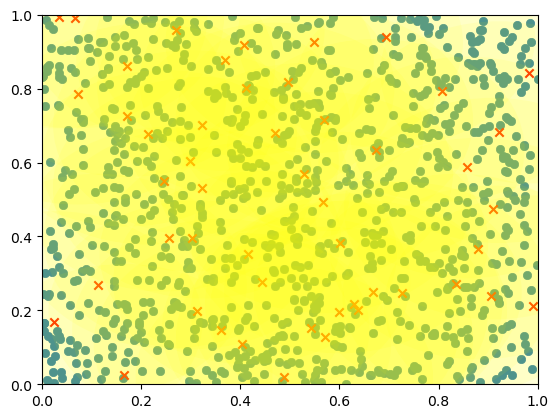

In [23]:
# Rayon du cercle
radius = 0.3 # =z de la génération du graphe

fig, ax = plt.subplots()
ax.scatter(coor_patients[:,0], coor_patients[:,1], lw=0.5)
ax.scatter(coor_doctors[:,0], coor_doctors[:,1], marker = "x", c="red")

for i in range(coor_doctors.shape[0]):
    # Ajouter un cercle autour du point
    circle = patches.Circle((coor_doctors[i,0], coor_doctors[i,1]), radius, linewidth=2, alpha=0.08, edgecolor='none', facecolor='yellow')
    ax.add_patch(circle)

plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

## Clustering

! Les cellules suivantes de cette section non plus d'importance si les ef sont générés de façon discrète !

#### Visualisation

In [134]:
patient_embedding_star = np.array(alpha_graph).flatten()
doctor_embedding_star = np.array(psi_graph).flatten()

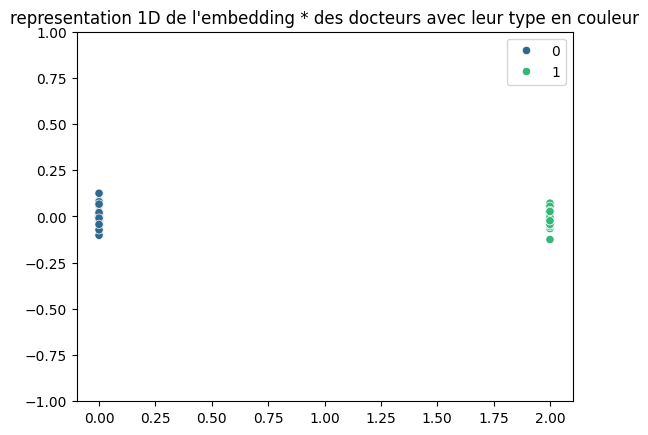

In [135]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_star, y= np.random.normal(0, 0.05, size=doctor_embedding_star.shape[0],), hue=psi_class, palette='viridis')
plt.title("representation 1D de l'embedding * des docteurs avec leur type en couleur")
plt.ylim(-1,1)
plt.show()

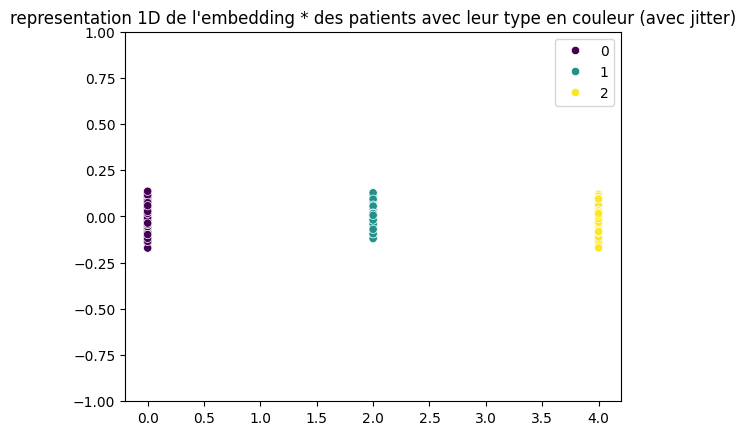

In [136]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_star, y= np.random.normal(0, 0.05, size=patient_embedding_star.shape[0],), hue=alpha_class, palette='viridis')
plt.title("representation 1D de l'embedding * des patients avec leur type en couleur (avec jitter)")
plt.ylim(-1,1)

plt.show()

#### K-means

In [105]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_p_star = KMeans(n_clusters=3, random_state=0)
# Ajuster le modèle sur les données
kmeans_p_star.fit(patient_embedding_star.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_patient_star = kmeans_p_star.labels_

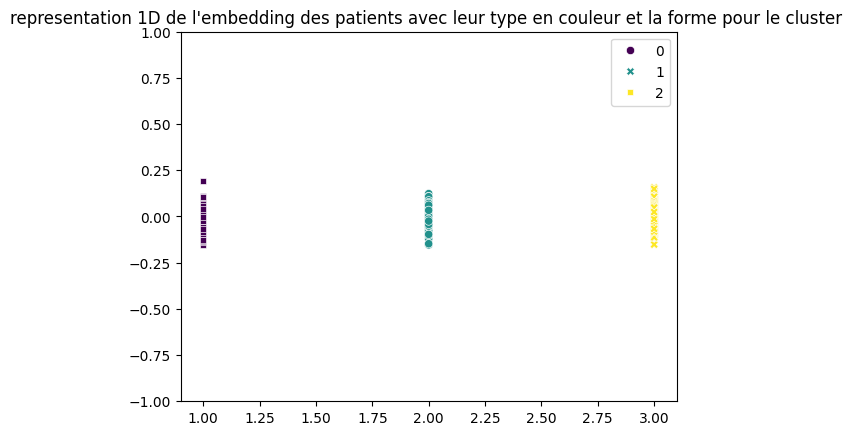

In [106]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_star, y= np.random.normal(0, 0.05, size=patient_embedding_star.shape[0],), hue=alpha_class, style = cluster_patient_star, palette='viridis')
plt.title("representation 1D de l'embedding des patients avec leur type en couleur et la forme pour le cluster ")
plt.ylim(-1,1)
plt.show()

In [107]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_d_star = KMeans(n_clusters=2, random_state=1)
# Ajuster le modèle sur les données
kmeans_d_star.fit(doctor_embedding_star.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_doctor_star = kmeans_d_star.labels_

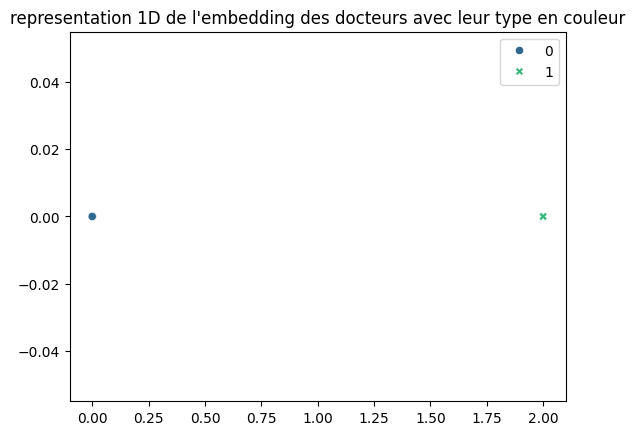

In [108]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_star, y= np.zeros(doctor_embedding_star.shape[0],), hue=psi_class, style=cluster_doctor_star, palette='viridis')
plt.title("representation 1D de l'embedding des docteurs avec leur type en couleur")

plt.show()

#### Measure

Pour mesurer la performance de notre clustering, nous allons utiliser le "Adjusted Mutual Information score" qui est une version ajustée du "Mutual Information score" afin de ramener à 0 le score pour un clustering aléatoire.

Le Mutual Information score est une mesure de la similartité entre deux "labels" du même jeu de données.
Soient $|U_{i}|$ le nombre d'observations dans le cluster (ou la classe) $U_{i}$ et $|V_{j}|$ le nombre d'observations dans le cluster. Le Mutual Information socre entre les deux partitions de clusters $U$ et $V$ est donnée  par l'expression suivante:

$MI(U,V) = \sum_{i} \sum_{j} \frac{|U_{i} \cap V_{j}|}{N}log \frac{N|U_{i} \cap V_{j}|}{|U_{i}| |V_{j}|}$

où $N$ est le nombre total d'observations 

Notons que la métrique est symétrique et indépendante de toute permutation entre les clusters (le label 0, 1, 2 ou même n'importe quoi sur tel ou tel cluster n'a pas d'importance)

L'Ajusted Mutual Information est donné par la formule:

$ AMI(U, V) = \frac{MI(U, V) - E(MI(U, V))}{avg(H(U), H(V)) - E(MI(U, V))} $

où $H(.)$ est l'entropie, dont l'expression est $H(U) := - \sum_{i=1}^{R} \frac{|U_{i}|}{N} log \frac{|U_{i}|}{N}$

Source pour plus de détails:

https://en.wikipedia.org/wiki/Adjusted_mutual_information
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score
https://jmlr.csail.mit.edu/papers/volume11/vinh10a/vinh10a.pdf

In [109]:
metric_doctor_star =  metrics.adjusted_rand_score(psi_class, cluster_doctor_star)
print(metric_doctor_star)

1.0


In [110]:
metric_patient_star =  metrics.adjusted_rand_score(alpha_class, cluster_patient_star)
print(metric_patient_star)

1.0


### Clustering sur l'Embedding estimé

In [169]:
patient_embedding_hat = np.array(ef_patient).flatten()
doctor_embedding_hat = np.array(ef_doctor).flatten()

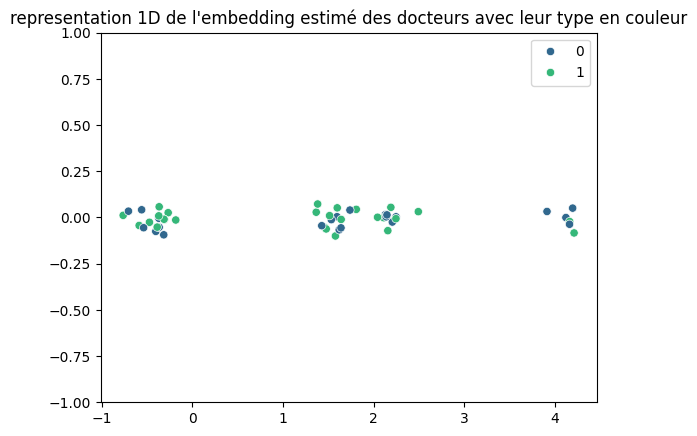

In [170]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_hat, y=np.random.normal(0, 0.05, size=doctor_embedding_hat.shape[0],), hue=psi_class, palette='viridis')
plt.title("representation 1D de l'embedding estimé des docteurs avec leur type en couleur")
plt.ylim(-1,1)
plt.show()

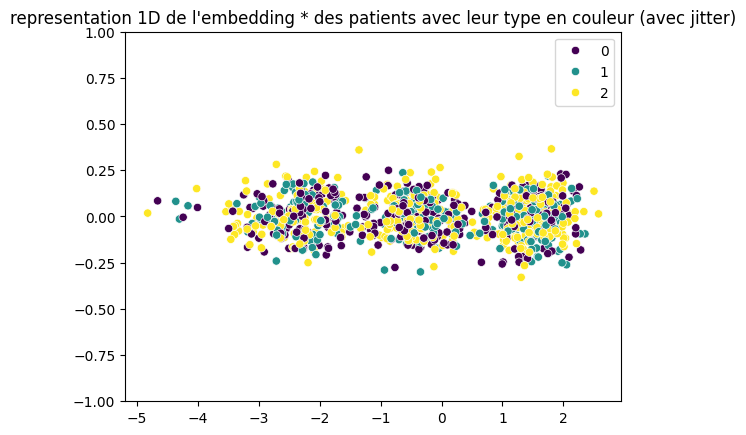

In [171]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_hat, y= np.random.normal(0, 0.1, size=patient_embedding_hat.shape[0],), hue=alpha_class, palette='viridis')
plt.title("representation 1D de l'embedding * des patients avec leur type en couleur (avec jitter)")
plt.ylim(-1,1)

plt.show()

In [148]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_d_hat = KMeans(n_clusters=2, random_state=1)
# Ajuster le modèle sur les données
kmeans_d_hat.fit(doctor_embedding_hat.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_doctor_hat = kmeans_d_hat.labels_

# Initialiser le modèle KMeans avec 4 clusters
kmeans_p_hat = KMeans(n_clusters=3, random_state=0)
# Ajuster le modèle sur les données
kmeans_p_hat.fit(patient_embedding_hat.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_patient_hat = kmeans_p_hat.labels_

In [149]:
metric_doctor_star =  metrics.adjusted_rand_score(psi_class, cluster_doctor_hat)
print(metric_doctor_star)

0.8432835820895522


In [150]:
metric_patient_star =  metrics.adjusted_rand_score(alpha_class, cluster_patient_hat)
print(metric_patient_star)

0.31686567452103803


## Etude de la qualité de prédiction du modèle

### Score de prédiction

In [49]:
# On prend 80% du dataframe
train_indices = int(df.shape[0]*0.8)
# L'argument drop=True permet de ne pas ajouter l'ancien index comme colonne supplémentaire dans le DataFrame
df_shuffled = df.sample(frac=1).reset_index(drop=True)
df_shuffled['age_p'] = (df_shuffled['age_p'] - df_shuffled['age_p'].mean())/df_shuffled['age_p'].std()
df_shuffled['age_d'] = (df_shuffled['age_d'] - df_shuffled['age_d'].mean())/df_shuffled['age_d'].std()

df_train ,df_test = df_shuffled.iloc[:train_indices,:] , df_shuffled.iloc[train_indices:,:]

In [56]:
estimates = get_estimations(df_train, nb_epochs=100, initial_weights=None, target_loss=None, show_print=0, regularization="l2")
model = estimates[4]
history = estimates[5]
loss = estimates[0]

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


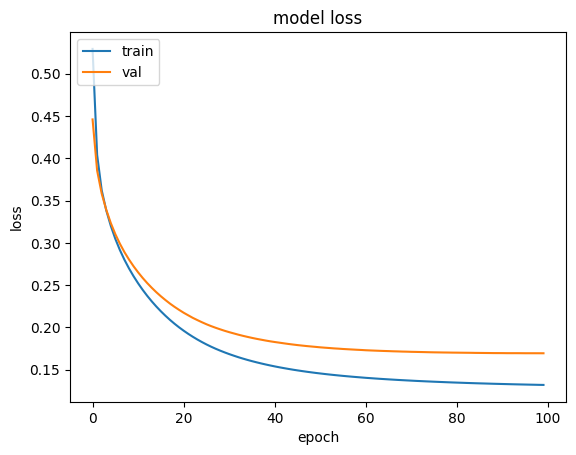

In [58]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [59]:
# Drop unwanted columns
X_test = df_test.drop(['y', 'class_p', 'class_d', 'ef_p_0', 'ef_d_0',], axis=1)

# Assurez-vous que les colonnes sont dans le bon ordre
input_data = [tf.constant(X_test[col].values.reshape(-1, 1), dtype=tf.float32) for col in X_test.columns]

# Predict
results = model.predict(input_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [60]:
y_true = df_test['y'].values.astype(int)
y_pred =  (results.flatten() > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
mse = np.sum((results.flatten()-df_test['y'])**2)/1500
print(f"Mean Squared Error sur l'échantillon de test : {mse}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Mean Squared Error sur l'échantillon de test : 0.33143172107338265
Precision: 0.78
Recall: 0.65
F1-score: 0.71


affichage de la matrice de confusion: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

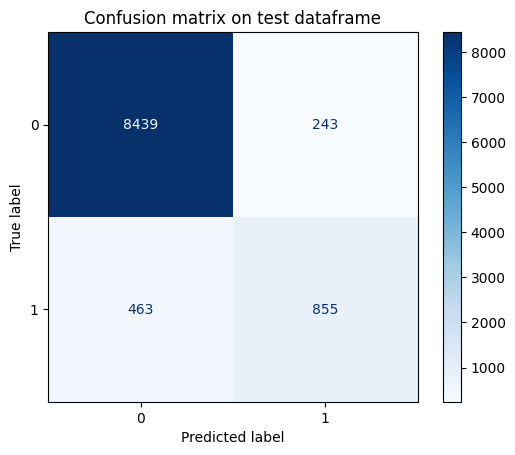

In [61]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
# Affiche la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix on test dataframe")
plt.show()

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


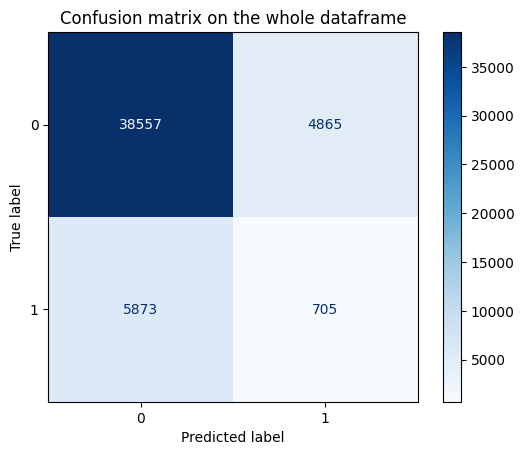

In [62]:
X_all = df_shuffled.drop(['y', 'class_p', 'class_d', 'ef_p_0', 'ef_d_0',], axis=1)
# Assurez-vous que les colonnes sont dans le bon ordre
input_data_all = [tf.constant(X_all[col].values.reshape(-1, 1), dtype=tf.float32) for col in X_all.columns]
# Predict
results_all = model.predict(input_data_all)

y_true_all = df['y'].values.astype(int)
y_pred_all =  (results_all.flatten() > 0.5).astype(int)

# Calculer la matrice de confusion
cm_all = confusion_matrix(y_true_all, y_pred_all)
# Affiche la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_all,)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix on the whole dataframe")
plt.show()

In [63]:
ef_patient = estimates[1][0]
ef_doctor = estimates[1][1]
beta_age_p = estimates[1][2]
beta_age_d = estimates[1][3]
beta_informed_p = estimates[1][4]
beta_skilled_d = estimates[1][5]
beta_distance = estimates[1][6]
print(f"ESTIMATION BETA: age p {beta_age_p}; age d {beta_age_d}; informed {beta_informed_p}; skilled {beta_skilled_d}; distance {beta_distance}")
print(f"ERROR ESTIMATION BETA: age p {beta_age_p-0.1}; age d {beta_age_d-0.1}; informed {beta_informed_p-1}; skilled {beta_skilled_d-1}; distance {beta_distance+20}")

ESTIMATION BETA: age p [0.17165767]; age d [0.3612485]; informed [1.4414846]; skilled [2.6845794]; distance [-16.890785]
ERROR ESTIMATION BETA: age p [0.07165767]; age d [0.2612485]; informed [0.44148457]; skilled [1.6845794]; distance [3.1092148]


### Simulation de n estimations avec sampling

In [124]:
def simul_n_models(n, train_ratio, df):
    # On va découper le df en 2 à partir de l'indice "train_indices"
    train_indices = int(df.shape[0]*train_ratio)
    
    matrix_ef_patient, matrix_ef_doctor = np.zeros((n,len(df['i'].unique()))), np.zeros((n,len(df['j'].unique())))

    beta_age_p, beta_age_d, beta_informed_p, beta_skilled_d, beta_distance = np.zeros(n,), np.zeros(n,), np.zeros(n,), np.zeros(n,), np.zeros(n,)
    
    for k in range(n):
        df_shuffled = df.sample(frac=1, random_state=k+1).reset_index(drop=True)
        df_train, df_test = df_shuffled.iloc[:train_indices,:] , df_shuffled.iloc[train_indices:,:]
        
        estimates = get_estimations(df_train, nb_epochs=80, initial_weights=None, target_loss=None, show_print=0, regularization="l2")
        
        matrix_ef_patient[k][:] = estimates[1][0].flatten()
        matrix_ef_doctor[k][:] = estimates[1][1].flatten()
        beta_age_p[k] = estimates[1][2]
        beta_age_d[k] = estimates[1][3]
        beta_informed_p[k] = estimates[1][4]
        beta_skilled_d[k] = estimates[1][5]
        beta_distance[k] = estimates[1][6]
        print(k+1)

    return matrix_ef_patient, matrix_ef_doctor, beta_age_p, beta_age_d, beta_informed_p, beta_skilled_d, beta_distance       

In [125]:
results = simul_n_models(100, 0.85, df)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/tmp/ipykernel_117/268928036.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_p[k] = estimates[1][2]
/tmp/ipykernel_117/268928036.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_d[k] = estimates[1][3]
/tmp/ipykernel_117/268928036.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25

1


/tmp/ipykernel_117/268928036.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_p[k] = estimates[1][2]
/tmp/ipykernel_117/268928036.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_d[k] = estimates[1][3]
/tmp/ipykernel_117/268928036.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_informed_p[k] = estimates[1][4]
/tmp/ipykernel_117/268928036.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, an

2


KeyboardInterrupt: 

In [327]:
# Enregistrer le tuple sur le disque
with open('results_simulation_85.pkl', 'wb') as f:
    pickle.dump(results, f)

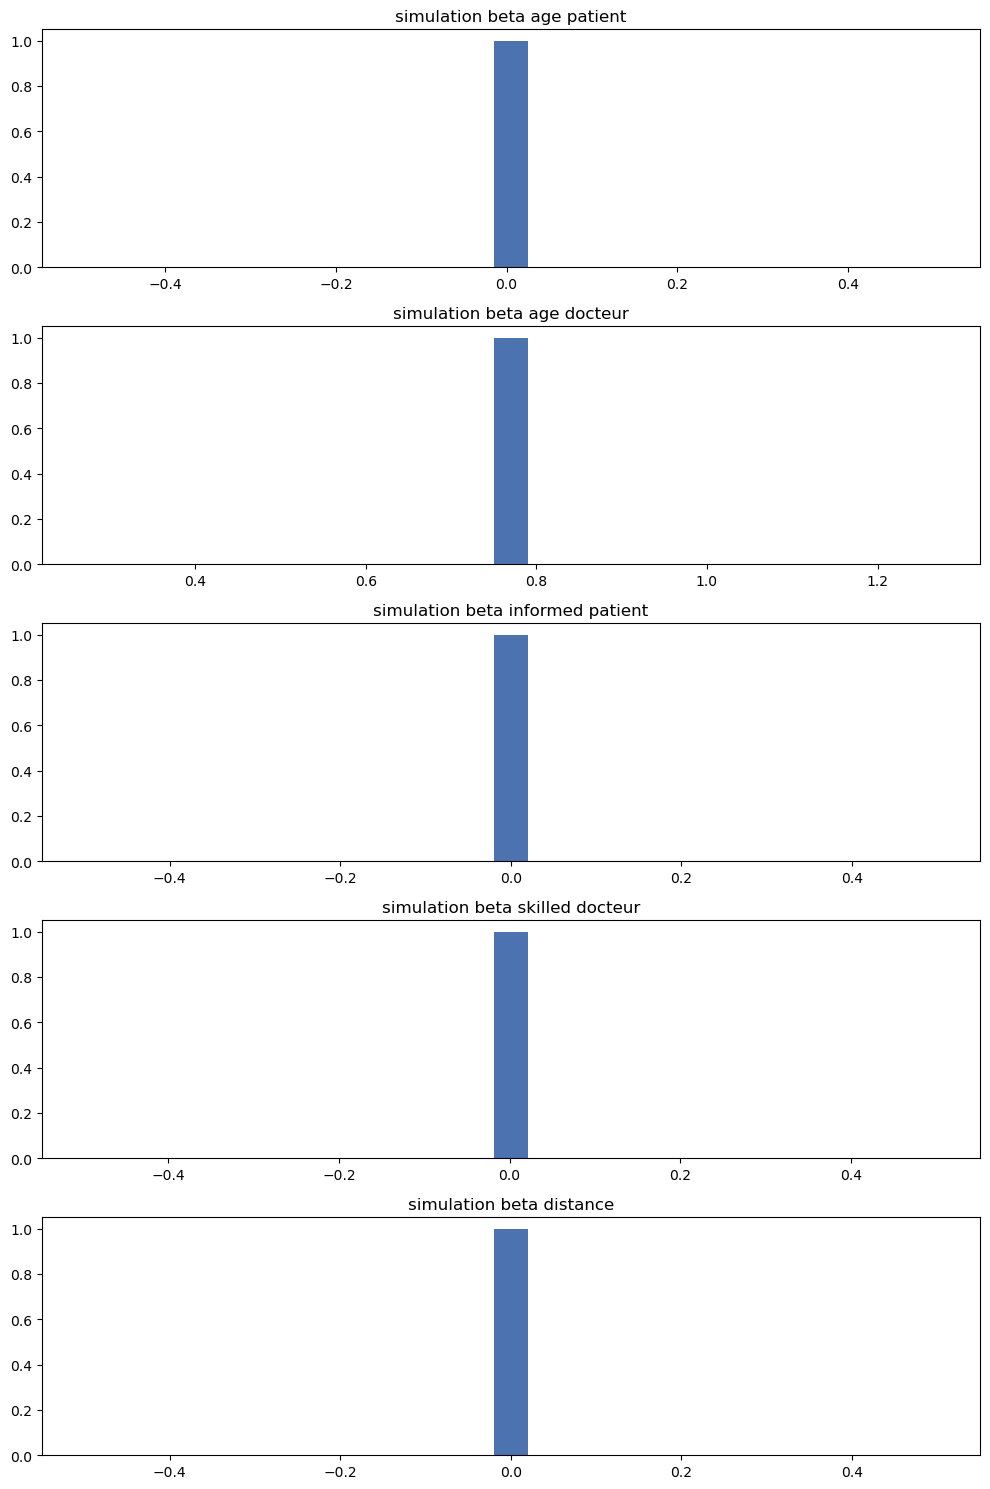

In [337]:
# Créer une figure avec plusieurs sous-graphiques
fig, axs = plt.subplots(5, 1, figsize=(10, 15))
title = ["simulation beta age patient", "simulation beta age docteur", "simulation beta informed patient", "simulation beta skilled docteur", "simulation beta distance"]
for k in [2,3,4,5,6]:
    axs[k-2].hist(results[k], bins=25)
    axs[k-2].set_title(title[k-2])
    
    # Ajouter un texte pour indiquer la moyenne
    #mean_value = np.mean(results[k])
    #axs[k-2].axvline(mean_value, color='red', linestyle='dashed', linewidth=2)
    #axs[k-2].text(mean_value, max(np.histogram(results[k], bins=25)[0]), f'Moyenne: {mean_value:.2f}', color='red')
    
# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()
plt.show()

In [310]:
def plot_simulation_n_ef(ef,ef_star, n, agent="patient"):
    fig, axs = plt.subplots(n, 1, figsize=(10, 15))
    # Exemple de liste
    list_indice = list(range(ef.shape[0]))
    # Échantillonnage de 5 éléments sans remise
    sampled_indice = random.sample(list_indice, n)

    for i,indice in enumerate(sampled_indice):
            axs[i].hist(ef[indice], bins=20)
            axs[i].set_title('effets fixes du '+ agent + f" {indice}")
            
            # Ajouter un texte pour indiquer la moyenne
            #axs[i].axvline(ef_star[indice], color='red', linestyle='dashed', linewidth=2)
            #axs[i].text(ef_star[indice], max(np.histogram(ef[indice], bins=20)[0]), f'effet fixe true: {ef_star[indice]:.2f}', color='red')
    
    # Ajuste l'espacement entre les sous-graphiques
    plt.tight_layout()
    plt.show()


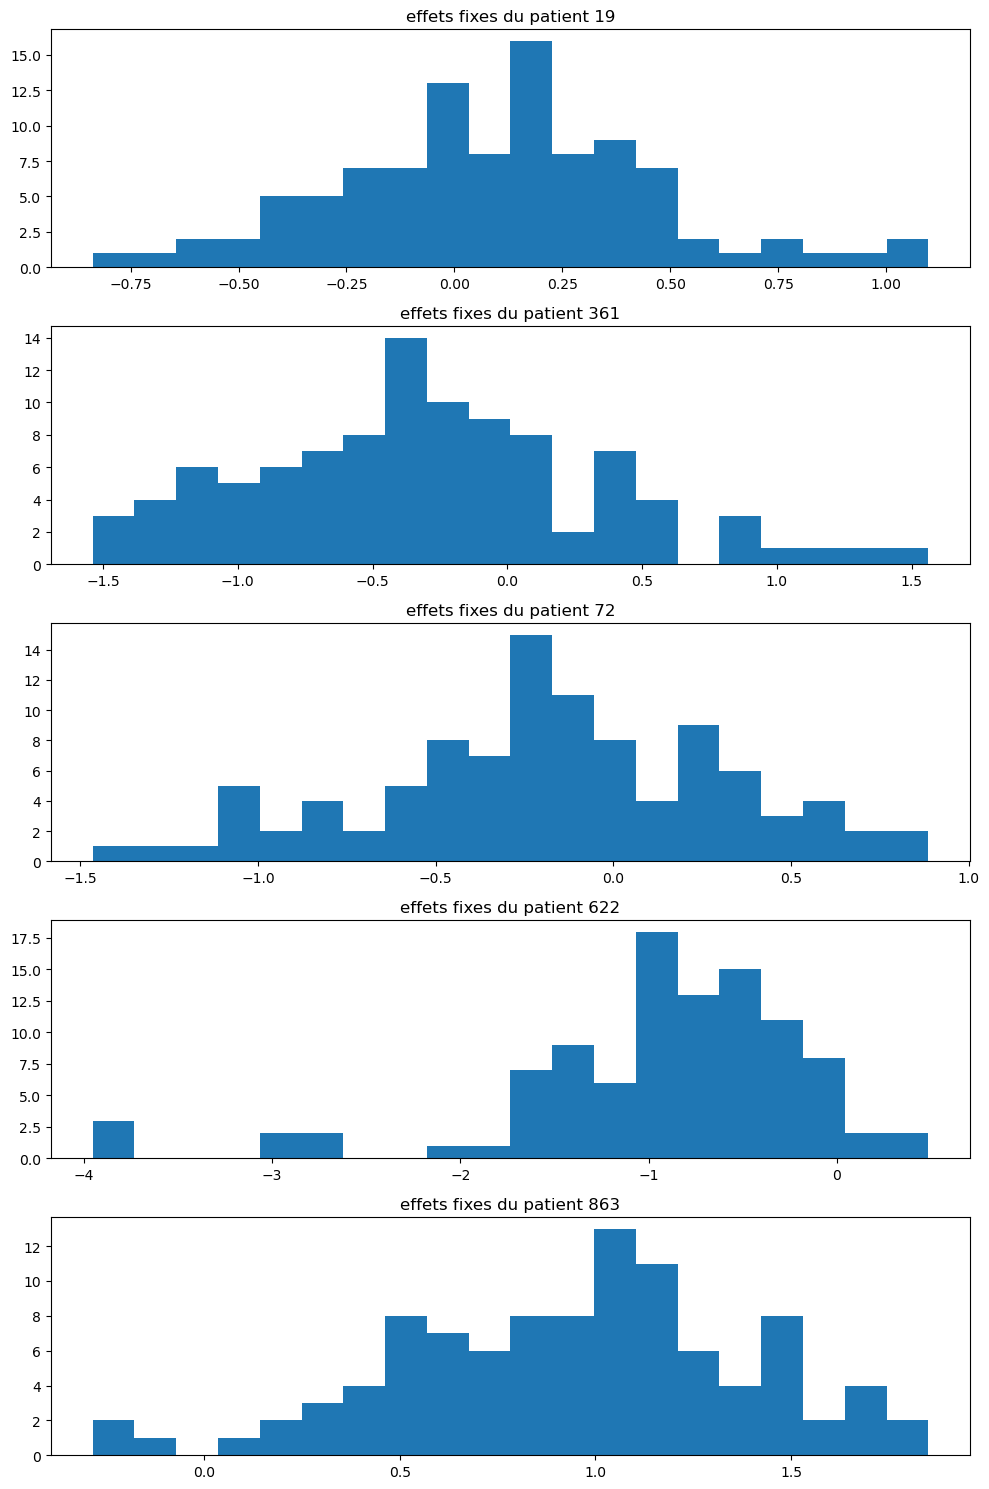

In [169]:
plot_simulation_n_ef(ef=np.transpose(results[0]), ef_star=np.array(alpha_graph).flatten(),n=5)

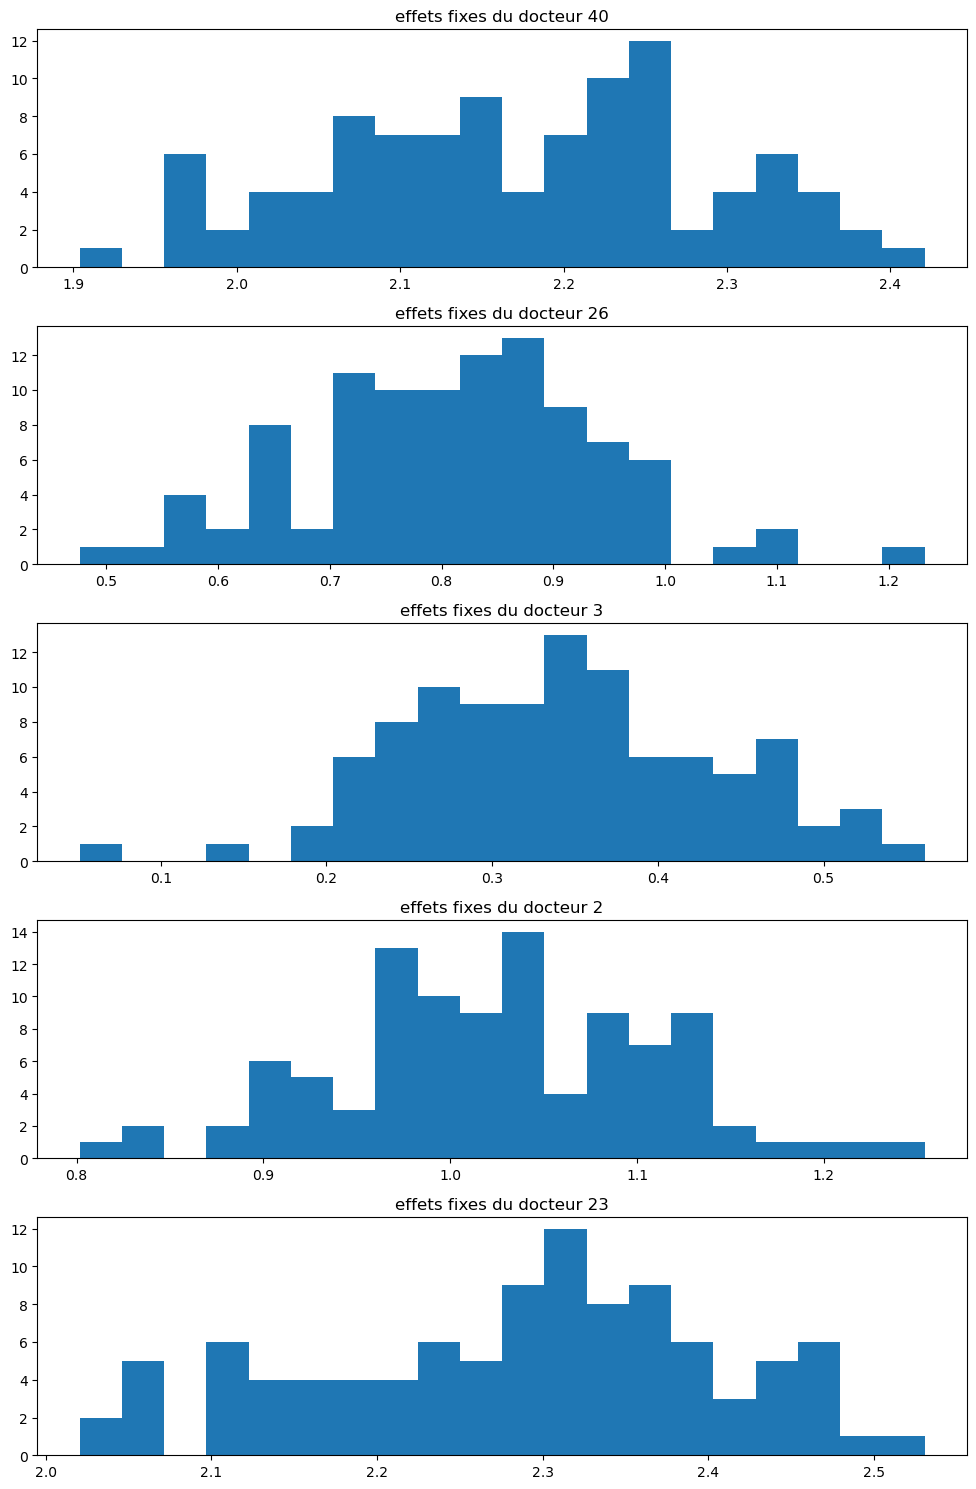

In [171]:
plot_simulation_n_ef(ef=np.transpose(results[1]), ef_star=np.array(psi_graph).flatten(),n=5, agent='docteur')

### score de similarité des matrices (robustesse des effets fixes)

Pour tester la robustesse des effets fixes, nous allons construire des matrices $A_{k}$ dont les composantes $(a_{ij}^{(k)})$ valent $|\alpha_{i}^{(k)} - \alpha_{j}^{(k)}|$   (ou $d(\alpha_{i}^{(k)},\alpha_{j}^{(k)})$ de façon plus général). Nous allons ensuite comparer la similarité entre ces matrices $A_{k}$.

In [ ]:
# Charger la variable depuis le disque
with open('results_simulation_85.pkl', 'rb') as f:
    results_simulation = pickle.load(f)

In [66]:
def make_distance_ef_matrix(ef):
    size = ef.shape[0]
    matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(i):
            matrix[i][j] = np.abs(ef[i] - ef[j])
    return matrix

def make_list_dist_ef_matrix(ef_simulation, triangle=True):
    l = []
    for k in range(ef_simulation.shape[0]):
        ef = ef_simulation[k]
        A_k = make_distance_ef_matrix(ef)
        if triangle==True:
            l.append(A_k)
        else:
            l.append(A_k + np.transpose(A_k))
    return l

In [67]:
distance_matrix_list_ef_patient_triangle = make_list_dist_ef_matrix(results_simulation[0])
distance_matrix_list_ef_docteur_triangle = make_list_dist_ef_matrix(results_simulation[1])
distance_matrix_list_ef_patient = make_list_dist_ef_matrix(results_simulation[0], triangle=False)
distance_matrix_list_ef_docteur = make_list_dist_ef_matrix(results_simulation[1], triangle=False)

IndexError: tuple index out of range

Les fonctions suivantes renvoient une matrice qui calculent la similarité entre les matrices de distance des effets fixes.

In [125]:
def compute_frobenius_norm(distance_matrix_list_ef, triangle=True):
    size = len(distance_matrix_list_ef)
    frobenius_distance = np.zeros((size,size))
    for i in range(size):
        for j in range(i):
            frobenius_distance[i][j] = norm(distance_matrix_list_ef[i] - distance_matrix_list_ef[j], 'fro')
    if triangle == True:
        return frobenius_distance + np.transpose(frobenius_distance)
    else:
        return frobenius_distance

def compute_cosine_similarity(distance_matrix_list_ef, triangle=True):
    size = len(distance_matrix_list_ef)
    cosine_sim = np.zeros((size,size))
    for i in range(size):
        for j in range(i):
            A_flat = distance_matrix_list_ef[i].flatten().reshape(1, -1)
            B_flat = distance_matrix_list_ef[j].flatten().reshape(1, -1)
            cosine_sim[i][j] = cosine_similarity(A_flat,B_flat)[0][0]
    if triangle == True:
        return cosine_sim + np.transpose(cosine_sim)
    else:
        return cosine_sim

def compute_pearson_corr(distance_matrix_list_ef, triangle=True):
    size = len(distance_matrix_list_ef)
    pearson_matrix = np.zeros((size,size))
    for i in range(size):
        for j in range(i):
            A_flat = distance_matrix_list_ef[i].flatten().reshape(1, -1)
            B_flat = distance_matrix_list_ef[j].flatten().reshape(1, -1)
            pearson_matrix[i][j] = np.corrcoef(A_flat, B_flat)[0, 1]
    if triangle == True:
        return pearson_matrix + np.transpose(pearson_matrix)
    else:
        return pearson_matrix

In [126]:
print( compute_frobenius_norm(distance_matrix_list_ef_patient_triangle).mean())
print( compute_frobenius_norm(distance_matrix_list_ef_docteur_triangle).mean()) 
print( compute_frobenius_norm(distance_matrix_list_ef_patient).mean())
print( compute_frobenius_norm(distance_matrix_list_ef_docteur).mean())

637.3263386996342
8.503061105416197
901.3155518466126
12.025144336966747


In [127]:
# On remarque que le score est invariant que la matrice de distance des ef est triangulaire ou non 
print( compute_cosine_similarity(distance_matrix_list_ef_patient_triangle).mean())
print( compute_cosine_similarity(distance_matrix_list_ef_docteur_triangle).mean()) 
#print( compute_cosine_similarity(distance_matrix_list_ef_patient).mean())
#print( compute_cosine_similarity(distance_matrix_list_ef_docteur).mean())

0.8283542602863563
0.9819711719670456


In [128]:
print( compute_pearson_corr(distance_matrix_list_ef_patient_triangle).mean())
print( compute_pearson_corr(distance_matrix_list_ef_docteur_triangle).mean()) 
print( compute_pearson_corr(distance_matrix_list_ef_patient).mean())
print( compute_pearson_corr(distance_matrix_list_ef_docteur).mean())

0.7539247936325634
0.9780571380954394
0.5524262230819148
0.9666965378056844


## RMSE vs density

In [92]:
def density(df):
    return len(df[df['y']==1])/len(df['y'])

def rmse(alpha_hat, psi_hat, alpha_star, psi_star):
    S = 0
    for i in range(len(alpha_hat)):
        for j in range(len(psi_hat)):
            S += (alpha_hat[i] + psi_hat[j] - psi_star[j] - alpha_star[i])**2
    return np.sqrt(S/(len(alpha_hat)*len(psi_hat)))
def rmse_psi(psi_hat, psi_star):
    S = 0
    for j in range(len(psi_hat)):
        S += (psi_hat[j] - psi_star[j])**2
        return np.sqrt(S/len(psi_hat))

def rmse_alpha(alpha_hat, alpha_star):
    S = 0
    for j in range(len(alpha_hat)):
        S += (alpha_hat[j] - alpha_star[j])**2
        return np.sqrt(S/len(alpha_hat))
    
def plot_rmsedensity( sim_beta_distance_array = [ -100, -50, -20, -10, -5,-2, -1] ):
    size = len(sim_beta_distance_array)
    density_array = np.zeros(size)
    beta_skilled_d, beta_age_d, beta_informed_p, beta_age_p, beta_distance = np.zeros(size), np.zeros(size), np.zeros(size), np.zeros(size) ,np.zeros(size)
    rmse_array, rmse_alpha_array, rmse_psi_array = np.zeros(size), np.zeros(size), np.zeros(size)
    ami_p_array, ami_d_array =  np.zeros(size), np.zeros(size)

    i=0
    for sim_beta_distance in sim_beta_distance_array:
    
        graph_all= graph_formation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                     z=1.4,
                    beta_distance_graph = sim_beta_distance)
       
        df, alpha_star, psi_star, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
        beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all
        
        density_array[i] = density(df)
        print(f"density: {100*density_array[i]:2f}%")

        df['age_p'] = (df['age_p'] - df['age_p'].mean())/df['age_p'].std()
        df['age_d'] = (df['age_d'] - df['age_d'].mean())/df['age_d'].std()
        
        estimates =  get_estimations(df, nb_epochs=80, initial_weights=None, target_loss=None, l_lambda=0, show_print=0)
        
        ef_patient_hat = np.array(estimates[1][0])
        ef_doctor_hat = np.array(estimates[1][1])
        beta_age_p[i] = estimates[1][2]
        beta_age_d[i] = estimates[1][3]
        beta_informed_p[i] = estimates[1][4]
        beta_skilled_d[i] = estimates[1][5]
        beta_distance[i] = estimates[1][6]
        print(f"BETA ESTIMATION ERROR: age patient:  {beta_age_p[i]-0.1}; age doctor: {beta_age_d[i]-0.1}; informed : {beta_informed_p[i]-1}; skilled: {beta_skilled_d[i]-1}; distance: {beta_distance[i] - sim_beta_distance}")  

        rmse_array[i] = rmse(ef_patient_hat, ef_doctor_hat, alpha_star, psi_star)
        rmse_alpha_array[i] = rmse_alpha(ef_patient_hat, alpha_star)
        rmse_psi_array[i] = rmse_psi(ef_doctor_hat, psi_star)


        # Initialise le modèle KMeans avec 3 et 2 clusters
        kmeans_p = KMeans(n_clusters=3, random_state=0)
        kmeans_d = KMeans(n_clusters=2, random_state=1)
        
        ef_patient_hat = np.array(ef_patient_hat).flatten()
        ef_doctor_hat = np.array(ef_doctor_hat).flatten()
        
        # Ajustement des Kmeans sur les ef estimés
        kmeans_p.fit(ef_patient_hat.reshape(-1,1))
        kmeans_d.fit(ef_doctor_hat.reshape(-1,1))
       
        # Ajouter les labels prédits au DataFrame
        cluster_patient = kmeans_p.labels_
        cluster_doctor = kmeans_d.labels_

        ami_p_array[i], ami_d_array[i]  = metrics.adjusted_rand_score(alpha_class, cluster_patient), metrics.adjusted_rand_score(psi_class, cluster_doctor)
        i+=1

    # Créer une figure avec deux sous-graphiques (subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    
    # Trace le premier graphique
    ax1.plot(density_array, rmse_array, label="Global RMSE")
    ax1.plot(density_array, rmse_alpha_array, label="RMSE of psi")
    ax1.plot(density_array, rmse_psi_array, label="RMSE of alpha")
    ax1.set_title("RMSE du graphe en fonction de sa densité")
    ax1.set_xlabel('density')
    ax1.set_ylabel('RMSE')
    ax1.legend()
    # Trace le deuxième graphique
    ax2.plot(density_array, ami_p_array, label="AMI pour les patients")
    ax2.plot(density_array, ami_d_array, label="AMI pour les doctors")
    ax2.set_title('AMI des ef estimés en fonction de la densité')
    ax2.set_xlabel('density')
    ax2.set_ylabel('AMI')
    ax2.legend()
    # Ajuste l'espace entre les sous-graphiques
    plt.tight_layout()
    plt.show()    
    
    return density_array, ami_p_array, ami_d_array, beta_age_p, beta_age_d, beta_informed_p, beta_skilled_d, beta_distance

density: 2.070000%


/tmp/ipykernel_117/1651668731.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/tmp/ipykernel_117/1133729228.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_p[i] = estimates[1][2]
/tmp/ipykernel_117/1133729228.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated N

BETA ESTIMATION ERROR: age patient:  -0.10760851567611099; age doctor: -0.08755470011383296; informed : -0.35706567764282227; skilled: 0.7665234804153442; distance: 75.0585765838623


/tmp/ipykernel_117/1133729228.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_array[i] = rmse(ef_patient_hat, ef_doctor_hat, alpha_star, psi_star)
/tmp/ipykernel_117/1133729228.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_alpha_array[i] = rmse_alpha(ef_patient_hat, alpha_star)
/tmp/ipykernel_117/1133729228.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_psi_array[i] = rmse_psi(ef_doctor_hat, psi_star)


density: 2.840000%


...

/tmp/ipykernel_117/1133729228.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_array[i] = rmse(ef_patient_hat, ef_doctor_hat, alpha_star, psi_star)
/tmp/ipykernel_117/1133729228.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_alpha_array[i] = rmse_alpha(ef_patient_hat, alpha_star)
/tmp/ipykernel_117/1133729228.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_psi_array[i] = rmse_psi(ef_doctor_hat, psi_star)


density: 92.890000%


/tmp/ipykernel_117/1651668731.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/tmp/ipykernel_117/1133729228.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_age_p[i] = estimates[1][2]
/tmp/ipykernel_117/1133729228.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated N

BETA ESTIMATION ERROR: age patient:  0.03731677830219268; age doctor: -0.09062765389680863; informed : -0.01726841926574707; skilled: 0.7512263059616089; distance: 0.1723276972770691


/tmp/ipykernel_117/1133729228.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_array[i] = rmse(ef_patient_hat, ef_doctor_hat, alpha_star, psi_star)
/tmp/ipykernel_117/1133729228.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_alpha_array[i] = rmse_alpha(ef_patient_hat, alpha_star)
/tmp/ipykernel_117/1133729228.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmse_psi_array[i] = rmse_psi(ef_doctor_hat, psi_star)


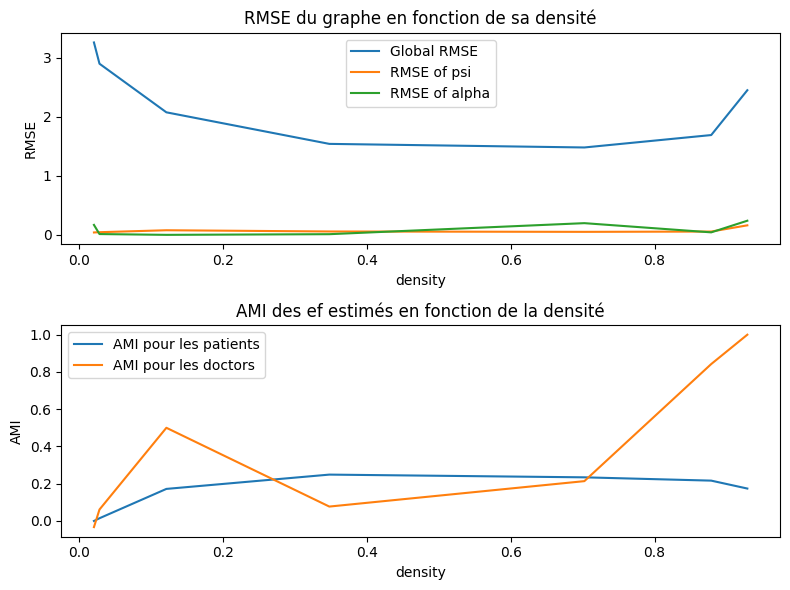

CPU times: user 19min 37s, sys: 3min 14s, total: 22min 51s
Wall time: 11min 13s


In [93]:
%%time
results = plot_rmsedensity()

## RMSE vs lambda_regularisation

In [305]:
def plot_rmsemlambda( regu_lambda = np.array([10**(-i) for i in range(9)]), regularization="l2" ):
    
    beta_skilled_d, beta_age_d, beta_informed_p, beta_age_p, beta_distance = np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)) ,np.zeros(len(regu_lambda))
    rmse_array, rmse_alpha_array, rmse_psi_array = np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda))
    for i,regu_lambda_ in enumerate(regu_lambda):
        graph_all= graph_formation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=20,
                     z=1.4,
                      )
        df, alpha_star, psi_star, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
        beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all


        
        df['age_p'] = (df['age_p'] - df['age_p'].mean())/df['age_p'].std()
        df['age_d'] = (df['age_d'] - df['age_d'].mean())/df['age_d'].std()
        
        estimates =  get_estimations(df, nb_epochs=100, initial_weights=None, target_loss=None, show_print=0, l_lambda = regu_lambda_, regularization="l2")
        alpha_hat = np.array(estimates[1][0])
        psi_hat = np.array(estimates[1][1])
        beta_age_p[i] = estimates[1][2]
        beta_age_d[i] = estimates[1][3]
        beta_informed_p[i] = estimates[1][4]
        beta_skilled_d[i] = estimates[1][5]
        beta_distance[i] = estimates[1][6]
        print(beta_age_p[i]-0.1, beta_age_d[i]-0.1, beta_informed_p[i]-1, beta_skilled_d[i]-1, beta_distance[i] + 20)  

        rmse_array[i] = rmse(alpha_hat, psi_hat, alpha_star, psi_star)
        rmse_alpha_array[i] = rmse_alpha(alpha_hat, alpha_star)
        rmse_psi_array[i] = rmse_psi(psi_hat, psi_star)

    plt.title(f"Rmse en fonction du lambda (10^(-i) pour l'échelle) de régularization " + regularization)
    plt.plot(np.arange(len(regu_lambda)), rmse_array, label="Global RMSE")
    plt.plot(np.arange(len(regu_lambda)), rmse_alpha_array, label="RMSE of psi")
    plt.plot(np.arange(len(regu_lambda)), rmse_psi_array, label="RMSE of alpha")
    plt.legend()
    plt.show()    
    return beta_age_p, beta_age_d, beta_informed_p, beta_skilled_d, beta_distance

0.0020997911691665594 0.3048898220062256 0.3561450242996216 0.281585693359375 8.975374221801758
0.032304280996322626 0.011825555562973017 0.39169251918792725 0.18049633502960205 9.602741241455078
0.022043430805206293 0.11620479226112365 0.39158689975738525 0.3604004383087158 9.680587768554688
0.049144291877746576 0.13783646523952484 0.2616337537765503 0.705164909362793 8.485787391662598
0.10030054450035095 -0.15823522806167603 0.24128210544586182 1.5700430870056152 5.348236083984375
0.12479282319545745 0.06014197468757629 0.32013440132141113 1.5941510200500488 3.016368865966797
0.051243254542350763 0.12819487750530242 0.6568551063537598 1.7368886470794678 1.9471168518066406
0.0790926307439804 0.18930604457855224 0.5244666337966919 1.573815107345581 2.5282669067382812
0.10675049722194671 -0.04767490774393082 0.3687978982925415 1.8465461730957031 1.9146232604980469


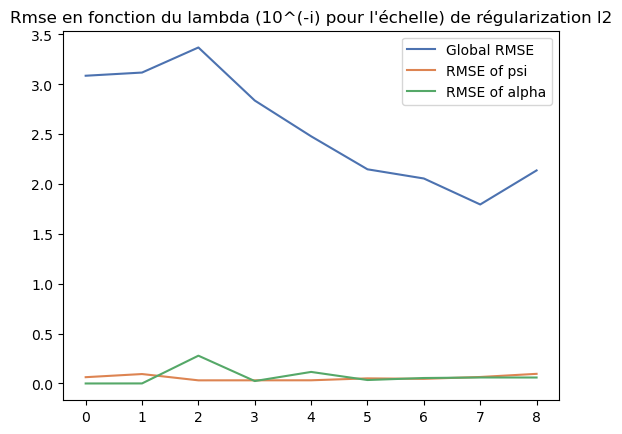

CPU times: total: 2min 34s
Wall time: 15min 29s


In [307]:
%%time
beta = plot_rmsemlambda()

0.08183138966560363 0.123225399851799 0.30364370346069336 0.5662616491317749 9.180665969848633
0.029662916064262385 0.04567990601062774 0.3114452362060547 0.5857946872711182 8.964532852172852
0.07957353591918945 -0.0036223441362381037 0.47260427474975586 0.25771868228912354 9.27706527709961
0.06344206035137176 0.04337113499641418 0.21791982650756836 0.7090258598327637 8.522601127624512
0.09606873393058776 0.06567395627498626 0.14309823513031006 1.3770074844360352 5.829246520996094
0.11306389570236205 0.0733580082654953 0.30832719802856445 1.4848453998565674 3.1041259765625
0.07872031033039092 0.30816450119018557 0.6088073253631592 1.612180471420288 2.0755367279052734
0.05445019304752349 -0.15384278297424317 0.4178506135940552 1.680147647857666 2.1788978576660156
0.02119512259960174 0.08430033326148986 0.4303908348083496 1.8415772914886475 1.7825241088867188


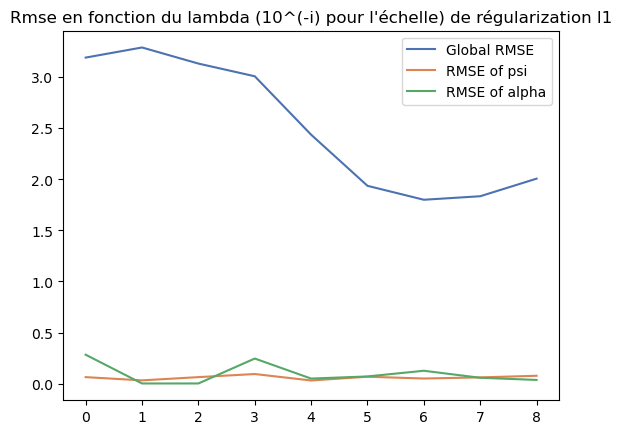

CPU times: total: 2min 33s
Wall time: 15min 33s


In [308]:
%%time
beta = plot_rmsemlambda(regularization='l1')

## Panel

### création des données panel

In [ ]:
def make_panel_df(T=5, 
                  n_patients=1000,
                    n_doctors=50,
                    max_number_connections=50,
                    z=1.4 ):

    graph_all= graph_formation(
                    n_patients=n_patients,
                     n_doctors=n_doctors,
                     max_number_connections=max_number_connections,
                     z=z )
    panel_df, alpha_graph, psi_graph, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
    beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all
    panel_df['y'] = panel_df['y'].astype("int")
    panel_df['period'] = np.zeros(n_patients*n_doctors)
    # Compile ids
    id_p = np.repeat(range(n_patients), n_doctors)
    id_d = np.tile(range(n_doctors), n_patients)
   
    for t in range(1,T):
        
        A = np.zeros([n_patients, n_doctors], dtype = np.ndarray)
        for i in range(n_patients):
            for j in range(n_doctors):
                if D[i][j] <= z: # if patient i and doctor j are too far away, there is no relation
                    doctor_data = panel_df[panel_df['j']==j]
                    patient_data = panel_df[panel_df['i']==i] 
                    T = alpha_graph[i] + psi_graph[j] + beta_age_p_star * sim_patient_age_normed[i] + beta_age_d_star * sim_doctor_age_normed[j] \
                        + beta_informed_p_star * sim_patient_informed[i] + beta_skilled_d_star * sim_doctor_skilled[j] + beta_distance_star * D[i][j]
                    p = 1 / (1 + np.exp(-T))
                    # P[i][j] = p
                    A[i][j] = np.random.binomial(1, p)
             # Compile relations between doctors and patients
        relation = A.flatten()
        # Merge all columns into a dataframe
        indices = n_doctors * n_patients
        df = pd.DataFrame(data={'i': id_p, 'j': id_d, 'y' : relation, 'age_p': panel_df['age_p'].head(indices) , 'age_d': panel_df['age_d'].head(indices), 
                           'informed_p': panel_df['informed_p'].head(indices), 'skilled_d': panel_df['skilled_d'].head(indices), 'class_p': panel_df['class_p'].head(indices), 'class_d': panel_df['class_d'].head(indices),
                             "distance": panel_df["distance"].head(indices), "ef_p_0": panel_df["ef_p_0"].head(indices), "ef_d_0": panel_df["ef_d_0"].head(indices),    
                                "period":np.ones(n_doctors*n_patients)*t
                            })
            
        panel_df = pd.concat([panel_df, df], ignore_index=True)
    return panel_df
    

In [154]:
panel_df = make_panel_df(T=5)

In [155]:
panel_df['y'] = panel_df['y'].astype("int")
panel_df[(panel_df["j"]==4) & (panel_df['i']==5)]

/opt/conda/lib/python3.12/site-packages/IPython/core/formatters.py:347: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,i,j,y,age_p,age_d,informed_p,skilled_d,class_p,class_d,distance,ef_p_0,ef_d_0,period
254,5,4,0,84,86,0,0,1,0,0.749406,2.0,0.0,0.0
50254,5,4,0,84,86,0,0,1,0,0.749406,2.0,0.0,1.0
100254,5,4,0,84,86,0,0,1,0,0.749406,2.0,0.0,2.0
150254,5,4,0,84,86,0,0,1,0,0.749406,2.0,0.0,3.0
200254,5,4,0,84,86,0,0,1,0,0.749406,2.0,0.0,4.0


In [156]:
panel_df['age_p'] = (panel_df['age_p']-panel_df['age_p'].mean())/panel_df['age_p'].std()
panel_df['age_d'] = (panel_df['age_d']-panel_df['age_d'].mean())/panel_df['age_d'].std()

### Score de prédiction panel

In [157]:
# On prend 80% du dataframe
train_indices = int(panel_df.shape[0]*0.8)
# L'argument drop=True permet de ne pas ajouter l'ancien index comme colonne supplémentaire dans le DataFrame
panel_shuffled = panel_df.sample(frac=1).reset_index(drop=True)
panel_train ,panel_test = panel_shuffled.iloc[:train_indices,:] , panel_shuffled.iloc[train_indices:,:]

In [158]:
estimates = get_estimations(panel_train, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0, regularization="l2")
model_panel = estimates[4]
history_panel = estimates[5]
loss = estimates[0]

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


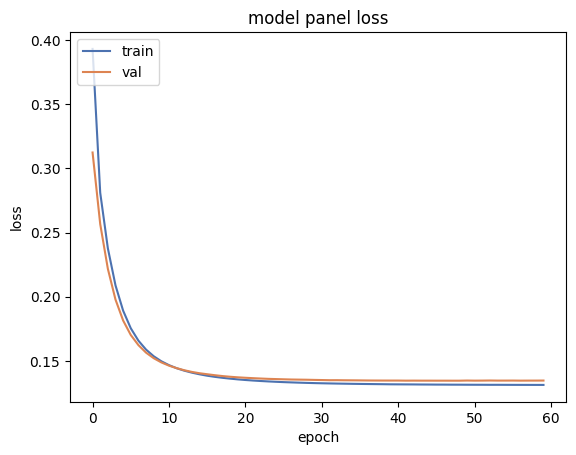

In [159]:
plt.plot(history_panel.history["loss"])
plt.plot(history_panel.history["val_loss"])
plt.title("model panel loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [160]:
# Drop unwanted columns
X_test = panel_test.drop(['y', 'class_p', 'class_d', 'ef_p_0', 'ef_d_0', 'period'], axis=1)

# Assurez-vous que les colonnes sont dans le bon ordre
input_data = [tf.constant(X_test[col].values.reshape(-1, 1), dtype=tf.float32) for col in X_test.columns]

# Predict
results = model_panel.predict(input_data)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [161]:
y_true = panel_test['y'].values.astype(int)
y_pred =  (results.flatten() > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
mse = np.sum((results.flatten()-panel_test['y'])**2)/1500
print(f"Mean Squared Error sur l'échantillon de test : {mse}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Mean Squared Error sur l'échantillon de test : 1.3863017721104849
Precision: 0.80
Recall: 0.73
F1-score: 0.76


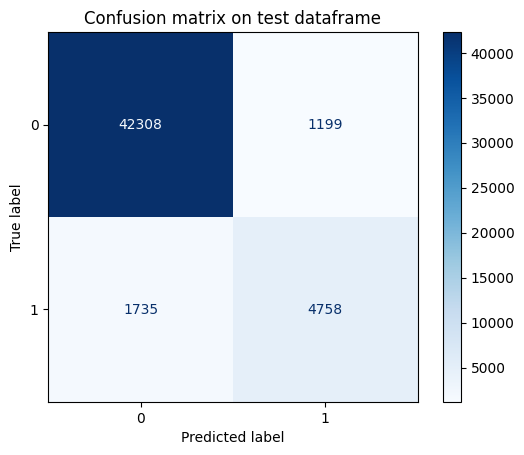

In [162]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
# Affiche la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix on test dataframe")
plt.show()

### estimation des paramètres

In [163]:
estimates = get_estimations(panel_train, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0)
ef_patient = estimates[1][0]
ef_doctor = estimates[1][1]
beta_age_p = estimates[1][2]
beta_age_d = estimates[1][3]
beta_informed_p = estimates[1][4]
beta_skilled_d = estimates[1][5]
beta_distance = estimates[1][6]

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [164]:
print(f"ESTIMATION BETA: age p {beta_age_p}; age d {beta_age_d}; informed {beta_informed_p}; skilled {beta_skilled_d}; distance {beta_distance}")
print(f"ERROR ESTIMATION BETA: age p {beta_age_p-0.1}; age d {beta_age_d-0.1}; informed {beta_informed_p-1}; skilled {beta_skilled_d-1}; distance {beta_distance+20}")

ESTIMATION BETA: age p [0.18929067]; age d [0.30816594]; informed [1.3310527]; skilled [3.574643]; distance [-19.396938]
ERROR ESTIMATION BETA: age p [0.08929067]; age d [0.20816594]; informed [0.33105266]; skilled [2.574643]; distance [0.6030617]


(array([16.,  1.,  0.,  0., 13., 11.,  3.,  0.,  0.,  6.]),
 array([-0.76326561, -0.26606116,  0.23114328,  0.72834772,  1.2255522 ,
         1.72275662,  2.21996117,  2.71716547,  3.21437001,  3.71157432,
         4.20877886]),
 <BarContainer object of 10 artists>)

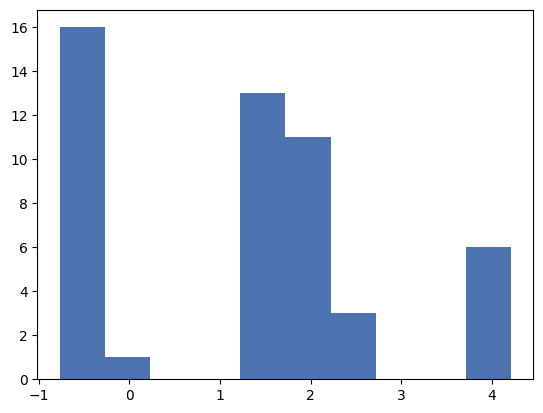

In [167]:
plt.hist(ef_doctor)

(array([  6.,  13.,  79., 149.,  66., 145., 141.,  74., 255.,  72.]),
 array([-4.81934738, -4.07978535, -3.34022355, -2.60066175, -1.86109972,
        -1.1215378 , -0.38197589,  0.35758603,  1.09714794,  1.83670986,
         2.57627177]),
 <BarContainer object of 10 artists>)

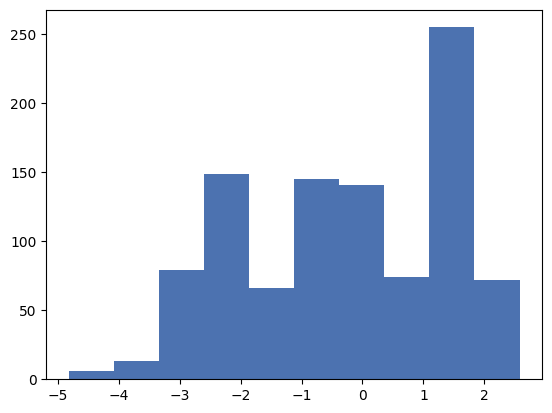

In [168]:
plt.hist(ef_patient)